# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

# **M16:** Inventarios Forestales Nacionales, cálculo de biomasa y evaluación del estado de los bosques nativos




**Grupo 1:**
- Ahumada, Magalí

- Martín, Nicolás Eugenio

- Nedel, Agustina Itatí

## **TP2 - Práctico de análisis exploratorio y curación de datos.**

En el TP1 se exploró el dataset del INBN2 y se **diagnosticó** el estado de los datos: dimensiones, tipos,
faltantes, duplicados, desbalance regional, correlaciones y valores atípicos. La curación quedó explícitamente
pendiente: allí se anticipó que "las decisiones de imputación definitiva o tratamiento estadístico de estas
variables se abordarán en el TP2".

Este práctico toma ese diagnóstico y lo convierte en **decisiones aplicadas**, dejando como resultado un dataset
curado y reproducible. El orden de trabajo es deliberado:

1. **Duplicados** (sección 2.2), porque definen cuál es la unidad de observación real de cada tabla.
2. **Errores de carga y consistencia interna** (2.3). Esta sección es nueva respecto del TP1 y va **antes** del
   tratamiento de faltantes: no tiene sentido imputar sobre columnas que están mal calculadas o mal escaladas,
   y además varios "faltantes" resultan ser en realidad valores imposibles cargados como cero.
3. **Valores faltantes** (2.4): se retoma la clasificación del TP1 (estructural / temporal / diseño / genuino) y
   ahora se define y aplica una acción por grupo.
4. **Selección de variables** (2.5): qué se conserva, qué se descarta y con qué criterio.
5. **Generación de nuevas variables** (2.6) a nivel individuo y a nivel unidad de muestreo.
6. **Transformaciones** (2.7): escalado y encoding de categóricas.
7. **Valores atípicos** (2.8): distinguir error de carga de variabilidad biológica real, cuantificar y decidir.
8. **Datasets curados** (2.9) y conclusiones.

Una aclaración metodológica que atraviesa todo el trabajo: el objetivo del proyecto es **caracterizar la
estructura y el estado de los bosques nativos**. Eso implica que un valor extremo (un árbol de 2 m de diámetro,
una parcela con 400 Tn/ha de biomasa) muchas veces es el dato más informativo del dataset y no ruido a eliminar.
Por eso la regla general que se adoptó es **conservar y documentar antes que borrar**, y eliminar únicamente lo
que es biológicamente imposible.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

sns.set_context('talk')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

### 2.1. Carga de datos y punto de partida

Se trabaja con la tabla general en su versión 2022 (en el TP1 se verificó que no es la 2021 con columnas
agregadas sino una revisión que recalculó buena parte de las variables comunes, por lo que se la adoptó como
fuente única) y con la tabla de individuos.

In [ ]:
url_tabla_2022 = 'https://raw.githubusercontent.com/AnibalCuchietti/Segundo-Inventario-Nacional-de-Bosques-Nativos-INBN2-/main/INF_ARG_UM_Tabla_general_2022.xlsx'
url_individuos = 'https://raw.githubusercontent.com/AnibalCuchietti/Segundo-Inventario-Nacional-de-Bosques-Nativos-INBN2-/main/data_individuos_pais_2021.csv'

df_um = pd.read_excel(url_tabla_2022, sheet_name='Tabla_general_2022 (2)')
df_ind = pd.read_csv(url_individuos, sep=';', low_memory=False)

# Copias crudas: se conservan intactas para poder comparar el antes y el después de la curación
df_um_crudo = df_um.copy()
df_ind_crudo = df_ind.copy()

print("Tabla general (UM):", df_um.shape)
print("Tabla individuos :", df_ind.shape)

Tabla general (UM): (3891, 78)
Tabla individuos : (101229, 31)


In [ ]:
def resumen_dataset(df, nombre):
    """Resumen compacto del estado de una tabla."""
    n_num = df.select_dtypes(include=np.number).shape[1]
    n_cat = df.shape[1] - n_num
    celdas = df.shape[0] * df.shape[1]
    return pd.Series({
        'filas': df.shape[0],
        'columnas': df.shape[1],
        'columnas numéricas': n_num,
        'columnas no numéricas': n_cat,
        'columnas con algún nulo': int((df.isnull().sum() > 0).sum()),
        '% de celdas nulas': round(df.isnull().sum().sum() / celdas * 100, 2),
        'filas duplicadas': int(df.duplicated().sum()),
    }, name=nombre)

estado_inicial = pd.concat([resumen_dataset(df_um, 'Tabla general (UM)'),
                            resumen_dataset(df_ind, 'Tabla individuos')], axis=1)
estado_inicial

,Tabla general (UM),Tabla individuos
filas,3891.00,101229.00
columnas,78.00,31.00
columnas numéricas,55.00,23.00
columnas no numéricas,23.00,8.00
columnas con algún nulo,72.00,10.00
% de celdas nulas,12.59,18.61
filas duplicadas,0.00,0.00


El punto de partida son 3.891 unidades de muestreo con 78 variables y 101.229 individuos con 31 variables.
Alrededor del 9% de las celdas de la tabla general están vacías y ninguna de las dos tablas tiene filas
duplicadas exactas. Sobre esa base se trabaja.

### 2.2. Duplicados

El TP1 ya había detectado y descartado un falso positivo: los 6.911 "duplicados" que aparecían al usar
`UM_ID_UM + NO_INDIV` como clave se debían a que la numeración de individuos se reinicia en cada parcela
concéntrica. Se retoma la verificación y se agrega un chequeo que no se había hecho: duplicados **de medición**,
es decir individuos distintos con exactamente los mismos valores medidos.

In [ ]:
chequeos_dup = {
    'UM - filas idénticas': df_um.duplicated().sum(),
    'UM - UM_ID_UM repetido': df_um['UM_ID_UM'].duplicated().sum(),
    'IND - filas idénticas': df_ind.duplicated().sum(),
    'IND - clave UM + NO_INDIV': df_ind.duplicated(subset=['UM_ID_UM', 'NO_INDIV']).sum(),
    'IND - clave UM + PARCELA + NO_INDIV': df_ind.duplicated(
        subset=['UM_ID_UM', 'PARCELA_CONCENTRICA', 'NO_INDIV']).sum(),
    'IND - mismas mediciones (UM + parcela + especie + DAP + altura)': df_ind.duplicated(
        subset=['UM_ID_UM', 'PARCELA_CONCENTRICA', 'ESPECIE_CORREGIDA', 'DAP_CM', 'ALTURA_TOTAL_M']).sum(),
}
pd.Series(chequeos_dup, name='casos')

,casos
UM - filas idénticas,0
UM - UM_ID_UM repetido,0
IND - filas idénticas,0
IND - clave UM + NO_INDIV,6911
IND - clave UM + PARCELA + NO_INDIV,0
IND - mismas mediciones (UM + parcela + especie + DAP + altura),895


La clave correcta de la tabla de individuos es `UM_ID_UM + PARCELA_CONCENTRICA + NO_INDIV`, que da 0 duplicados
y confirma el diagnóstico del TP1.

El chequeo nuevo sí devuelve 895 casos: individuos con distinto número que comparten parcela, especie, diámetro
y altura. **No se eliminan.** Que dos quebrachos de la misma parcela midan ambos 10,5 cm de DAP y 6,3 m de altura
no es un error de carga: el DAP se releva con precisión de milímetros y la altura en decenas de centímetros, con
lo cual las coincidencias son estadísticamente esperables en parcelas con decenas de individuos de la misma
especie y edad. Eliminarlos sería borrar árboles reales y subestimar la densidad del rodal, que es justamente una
de las variables de interés.

**Decisión: no se elimina ninguna fila por duplicados en ninguna de las dos tablas.**

In [ ]:
# ¿Se concentran en pocas parcelas o están dispersos? ¿Sesgan alguna región?
duplicados_medicion = df_ind[df_ind.duplicated(
    subset=['UM_ID_UM', 'PARCELA_CONCENTRICA', 'ESPECIE_CORREGIDA', 'DAP_CM', 'ALTURA_TOTAL_M'],
    keep=False
)]

por_um = duplicados_medicion.groupby('UM_ID_UM').size()
print(f"Casos en {por_um.shape[0]} UM distintas (de {df_um.shape[0]} totales)")
print("Máx. casos duplicados en una misma UM:", por_um.max())

# Impacto en densidad de individuos por región
impacto_region = duplicados_medicion['REGION_OFC'].value_counts(normalize=True).round(3)
print("\nDistribución regional de estos casos vs. distribución general:")
print(impacto_region)
print(df_ind['REGION_OFC'].value_counts(normalize=True).round(3))

Casos en 484 UM distintas (de 3891 totales)
Máx. casos duplicados en una misma UM: 51

Distribución regional de estos casos vs. distribución general:
REGION_OFC
PCH    0.656
MON    0.155
BAP    0.140
ESP    0.038
STB    0.006
SMI    0.004
DEL    0.002
Name: proportion, dtype: float64
REGION_OFC
PCH    0.756
ESP    0.069
BAP    0.068
STB    0.051
SMI    0.030
MON    0.020
DEL    0.006
Name: proportion, dtype: float64


Los 895 casos se reparten entre 484 UM distintas (de 3.891 totales), sin un único foco extremo aunque con hasta 51 casos en una misma parcela. La distribución regional, sin embargo, no es pareja: el Monte (2,0% de los individuos totales) concentra el 15,5% de estos casos, y el Bosque Andino Patagónico pasa de 6,8% a 14,0%, mientras que el Parque Chaqueño está subrepresentado (75,6% → 65,6%). Es coherente con la
estructura de esos bosques: MON y BAP suelen tener rodales más homogéneos en tamaño (monte xerófilo y bosques de *Nothofagus* casi coetáneos), donde coincidencias exactas de DAP y altura entre individuos de la misma especie son más esperables que en el Chaqueño, más diverso estructuralmente. No cambia la decisión de no eliminarlos, pero sí matiza el motivo: no es ruido disperso, es un patrón regional explicable por la fisonomía del bosque.

### 2.3. Errores de carga y consistencia interna

Antes de decidir qué hacer con los faltantes conviene verificar que lo que **no** está faltante sea correcto.
En esta sección se cruzan variables que deberían guardar una relación matemática conocida (área basal con
diámetro, agregados de parcela con la suma de sus individuos, coordenadas con el rango geográfico de Argentina)
y se corrige lo que no cierra.

#### 2.3.1. Área basal a nivel individuo

El área basal de un árbol es la sección del tronco a la altura del pecho: $AB = \pi \cdot (DAP/2)^2$. Es una
relación exacta, así que se puede recalcular desde `DAP_CM` y comparar con la columna del dataset.

In [ ]:
ab_teorica_m2 = np.pi * (df_ind['DAP_CM'] / 200) ** 2   # DAP en cm -> radio en m

comparacion_ab = pd.DataFrame({
    'DAP_CM': df_ind['DAP_CM'],
    'AREABASAL_CM2 (dataset)': df_ind['AREABASAL_CM2'],
    'AREABASAL_M2 (dataset)': df_ind['AREABASAL_M2'],
    'AB teórica m2': ab_teorica_m2,
})
comparacion_ab['ratio dataset/teórica'] = (comparacion_ab['AREABASAL_M2 (dataset)'] / ab_teorica_m2).round(3)

print("Distribución del cociente entre el valor del dataset y el valor teórico:")
print(comparacion_ab['ratio dataset/teórica'].value_counts(dropna=False).head().to_string())

print("\nCociente por región:")
print(pd.crosstab(df_ind['REGION_OFC'], comparacion_ab['ratio dataset/teórica'],
                  dropna=False).to_string())

Distribución del cociente entre el valor del dataset y el valor teórico:
ratio dataset/teórica
0.01    76486
1.00    23762
inf       981

Cociente por región:
ratio dataset/teórica   0.01  1.00  inf 
REGION_OFC                              
BAP                        0  6908     0
DEL                        0   628     0
ESP                        0  7008     0
MON                        0  1003   981
PCH                    76486     0     0
SMI                        0  3079     0
STB                        0  5136     0


El cociente toma sólo dos valores, y el cruce por región muestra por qué: **`AREABASAL_M2` está 100 veces por
debajo del valor correcto en los 76.486 individuos del Parque Chaqueño, y es correcta en todas las demás
regiones**. `AREABASAL_CM2` arrastra el mismo error (es exactamente 10.000 veces `AREABASAL_M2`). Los 981
cocientes infinitos corresponden a los individuos arbustivos con DAP = 0, donde el área teórica es cero.

Que el error sea regional y no global descarta un problema conceptual de fórmula y apunta a un error de
procesamiento en el armado de la tabla: el bloque del Parque Chaqueño se construyó con una conversión de
unidades distinta a la del resto. Es exactamente el tipo de error que un análisis por región no detecta (dentro
del PCH todos los valores son coherentes entre sí) y que sólo aparece al contrastar contra una relación
matemática conocida.

El impacto potencial no es menor: el PCH concentra el 76% de los individuos del dataset, así que cualquier
estadística de área basal calculada a nivel de individuo sobre el país entero estaría dominada por valores
erróneos. Se recalcula la variable desde el diámetro para todos los individuos y se conservan las originales
renombradas, para dejar trazabilidad.

In [ ]:
df_ind['AREA_BASAL_M2'] = np.pi * (df_ind['DAP_CM'] / 200) ** 2
df_ind = df_ind.rename(columns={'AREABASAL_M2': 'AREABASAL_M2_ORIGINAL',
                                'AREABASAL_CM2': 'AREABASAL_CM2_ORIGINAL'})

print("Área basal mediana por región (sólo individuos con DAP > 0), antes y después de la corrección:")
print(df_ind.loc[df_ind['DAP_CM'] > 0]
      .groupby('REGION_OFC')[['AREABASAL_M2_ORIGINAL', 'AREA_BASAL_M2']].median().round(5).to_string())

Área basal mediana por región (sólo individuos con DAP > 0), antes y después de la corrección:
            AREABASAL_M2_ORIGINAL  AREA_BASAL_M2
REGION_OFC                                      
BAP                       0.06560        0.06560
DEL                       0.01875        0.01875
ESP                       0.01606        0.01606
MON                       0.00920        0.00920
PCH                       0.00015        0.01496
SMI                       0.04481        0.04481
STB                       0.04909        0.04909


#### 2.3.2. Factor de expansión y validación de los agregados de parcela

El INBN2 usa parcelas concéntricas: los individuos chicos se miden en una superficie menor que los grandes, y
cada uno se "expande" a hectárea con un factor distinto. Ese factor no está documentado como columna, pero se
puede deducir dividiendo `VOL_M3_HA` por `VOL_M3` dentro de la tabla de individuos.

In [ ]:
factor = (df_ind['VOL_M3_HA'] / df_ind['VOL_M3']).round(2)
print(factor.groupby(df_ind['PARCELA_CONCENTRICA']).agg(['count', 'median', 'min', 'max']))

FACTOR_EXPANSION = {'A': 10.0, 'B': 39.3}
df_ind['FACTOR_EXPANSION'] = df_ind['PARCELA_CONCENTRICA'].map(FACTOR_EXPANSION)

                     count  median   min   max
PARCELA_CONCENTRICA                           
A                    75048    10.0  10.0  10.0
B                    25194    39.3  39.3  39.3


El factor es constante dentro de cada parcela: **10 para la parcela A y 39,3 para la B** (equivalen a
superficies de 1.000 m² y 254 m² respectivamente). Con eso se pueden recalcular los agregados de la tabla
general desde los individuos y verificar que ambas tablas son consistentes entre sí.

In [ ]:
df_ind['_ab_ha'] = df_ind['AREA_BASAL_M2'] * df_ind['FACTOR_EXPANSION']
df_ind['_biom_ha'] = df_ind['BIOMASA_KG'] * df_ind['FACTOR_EXPANSION'] / 1000
df_ind['_vol_ha'] = df_ind['VOL_M3'] * df_ind['FACTOR_EXPANSION']

recalculado = df_ind.groupby('UM_ID_UM').agg(
    area_basal_ha_calc=('_ab_ha', 'sum'),
    biomasa_tn_ha_calc=('_biom_ha', 'sum'),
    vol_m3_ha_calc=('_vol_ha', 'sum'),
    n_ind_ha_calc=('FACTOR_EXPANSION', 'sum'),
).reset_index()

df_ind = df_ind.drop(columns=['_ab_ha', '_biom_ha', '_vol_ha'])

validacion = df_um[['UM_ID_UM', 'AREA_BASAL_UM_HA', 'BIOMASA_TN_HA', 'VOL_M3_HA',
                    'CANTIDAD_IND_VIVOS_HA']].merge(recalculado, on='UM_ID_UM')

filas = []
for original, calculada in [('AREA_BASAL_UM_HA', 'area_basal_ha_calc'),
                            ('BIOMASA_TN_HA', 'biomasa_tn_ha_calc'),
                            ('VOL_M3_HA', 'vol_m3_ha_calc'),
                            ('CANTIDAD_IND_VIVOS_HA', 'n_ind_ha_calc')]:
    ratio = (validacion[original] / validacion[calculada]).replace([np.inf, -np.inf], np.nan)
    filas.append({'variable': original,
                  'correlación': round(validacion[original].corr(validacion[calculada]), 4),
                  'ratio mediano': round(ratio.median(), 4),
                  'UM con desvío > 5%': int(((ratio - 1).abs() > 0.05).sum())})
pd.DataFrame(filas)

,variable,correlación,ratio mediano,UM con desvío > 5%
0,AREA_BASAL_UM_HA,0.9995,1.0,86
1,BIOMASA_TN_HA,0.9901,1.0,14
2,VOL_M3_HA,0.9816,1.0,77
3,CANTIDAD_IND_VIVOS_HA,0.9998,1.0,77


El recálculo reproduce los agregados de la tabla general con ratio mediano 1,000 y correlaciones de 0,98 a 1,00.
Dos conclusiones importantes:

- **La tabla general está bien calculada.** El error de unidades de 2.3.1 afecta sólo a la columna de área basal
  de la tabla de individuos, no a `AREA_BASAL_UM_HA`, que fue construida con el valor correcto.
- **El cruce entre tablas es sólido**, lo que habilita a generar variables nuevas a nivel de parcela agregando
  desde individuos (sección 2.6) con la garantía de que van a ser comparables con las que ya existen.

Las UM que sí muestran desvío corresponden a los casos de reclasificación de individuos ya identificados en el
TP1 (91,6% de coincidencia exacta en el conteo). La excepción sistemática es el Monte, donde el recálculo queda
por debajo del valor de la tabla general porque los individuos arbustivos no tienen DAP y por lo tanto no
aportan área basal al agregado reconstruido.

#### 2.3.3. Coordenadas de la tabla general

El TP1 detectó que `LATITUD_*` y `LONGITUD_*` de la tabla general están en el orden de millones o miles de
millones en lugar de grados decimales, y resolvió el problema promediando las coordenadas GPS de los individuos
de cada parcela. Eso funciona, pero deja sin ubicación a las 76 UM que no tienen individuos. Vale la pena mirar
el error con más detalle antes de descartar las columnas.

In [ ]:
orden_magnitud = pd.DataFrame({
    c: np.floor(np.log10(df_um[c].abs().replace(0, np.nan))).value_counts().sort_index()
    for c in ['LATITUD_GRILLA', 'LONGITUD_GRILLA', 'LATITUD_INSTALACION', 'LONGITUD_INSTALACION']
}).fillna(0).astype(int)
orden_magnitud.index.name = 'orden de magnitud (10^n)'
orden_magnitud

,LATITUD_GRILLA,LONGITUD_GRILLA,LATITUD_INSTALACION,LONGITUD_INSTALACION
orden de magnitud (10^n),,,,
2.0,0,0,1,0
3.0,0,1,8,13
4.0,4,6,101,85
5.0,40,44,156,159
6.0,371,347,257,232
7.0,3475,3492,9,3
9.0,0,0,3354,3394


El error no es un factor de escala único: conviven valores de 10³ a 10⁹ en la misma columna. Eso descarta la
hipótesis de "multiplicaron todo por un millón" y apunta a lo que en la práctica es más común, la **pérdida del
separador decimal** al exportar el archivo. Si el punto desaparece, `-26.1084` queda como `-261084`, y la
magnitud resultante depende de cuántos decimales tenía el valor original.

Bajo esa hipótesis el valor es recuperable: alcanza con dividir por 10 hasta que caiga dentro del rango
geográfico de Argentina continental (latitud entre -22 y -55, longitud entre -53 y -74).

In [ ]:
def recuperar_coordenada(serie, minimo, maximo):
    """Divide por 10 hasta que el valor caiga en el rango esperado (recupera el separador decimal perdido)."""
    valores = pd.to_numeric(serie, errors='coerce').astype(float)
    for _ in range(12):
        fuera = valores.notna() & ((valores.abs() < abs(minimo)) | (valores.abs() > abs(maximo)))
        if not fuera.any():
            break
        valores.loc[fuera] = valores.loc[fuera] / 10
    return valores

df_um['LATITUD'] = recuperar_coordenada(df_um['LATITUD_GRILLA'], 22, 55)
df_um['LONGITUD'] = recuperar_coordenada(df_um['LONGITUD_GRILLA'], 53, 74)

print(df_um[['LATITUD', 'LONGITUD']].describe().round(4).loc[['min', '50%', 'max']])

     LATITUD  LONGITUD
min -54.9676  -73.2757
50% -26.7122  -63.0367
max -22.0463  -53.6999


In [ ]:
# Validación independiente: comparar contra el promedio de las coordenadas GPS de los individuos de cada UM
coords_gps = (df_ind.groupby('UM_ID_UM')[['COORDENADAS_GPS_LATITUDE2', 'COORDENADAS_GPS_LONGITUDE2']]
              .mean().reset_index())
control = df_um[['UM_ID_UM', 'LATITUD', 'LONGITUD']].merge(coords_gps, on='UM_ID_UM')
distancia_grados = np.hypot(control['LATITUD'] - control['COORDENADAS_GPS_LATITUDE2'],
                            control['LONGITUD'] - control['COORDENADAS_GPS_LONGITUDE2'])

print("Diferencia entre la coordenada recuperada y el GPS de los individuos (en grados):")
print(distancia_grados.describe([0.5, 0.9, 0.99]).round(5))
print(f"\nUM con diferencia menor a 0,01° (~1 km): {(distancia_grados < 0.01).mean()*100:.1f}%")

Diferencia entre la coordenada recuperada y el GPS de los individuos (en grados):
count    3815.00000
mean        0.00009
std         0.00160
min         0.00000
50%         0.00002
90%         0.00006
99%         0.00101
max         0.09801
dtype: float64

UM con diferencia menor a 0,01° (~1 km): 100.0%


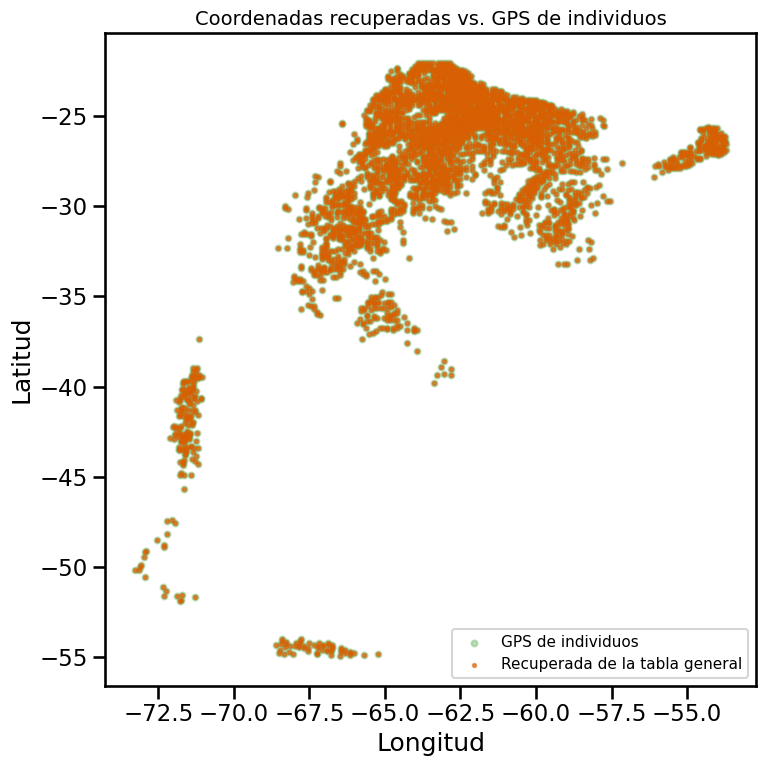

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(control['COORDENADAS_GPS_LONGITUDE2'], control['COORDENADAS_GPS_LATITUDE2'],
           s=18, alpha=0.5, label='GPS de individuos', color='#7fbf7b')
ax.scatter(control['LONGITUD'], control['LATITUD'],
           s=6, alpha=0.6, label='Recuperada de la tabla general', color='#d95f02')
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Coordenadas recuperadas vs. GPS de individuos', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

La recuperación es exacta: la diferencia mediana contra el GPS de los individuos es de 0,0000° y el 99% de las
UM cae por debajo de 0,001° (unos 100 metros). Los dos conjuntos de puntos se superponen completamente.

**Decisión:** se conservan `LATITUD` y `LONGITUD` recuperadas como coordenadas oficiales de la UM. La ventaja
sobre el método del TP1 es que ahora **las 3.891 UM tienen posición**, incluidas las 76 sin individuos, lo que
permite usar la ubicación como insumo para imputar otras variables (se usa en 2.4 para la altitud).

#### 2.3.4. Altitud igual a cero

`ALTITUD` tiene 47 nulos declarados, pero además 122 UM con valor 0 m.s.n.m. Conviene mirar dónde están.

In [ ]:
print("UM con ALTITUD = 0, por región:")
print(df_um.loc[df_um['ALTITUD'] == 0, 'REGION_OFC'].value_counts().to_string())
print("\nAltitud del resto del Parque Chaqueño (PCH):")
print(df_um.loc[(df_um['REGION_OFC'] == 'PCH') & (df_um['ALTITUD'] > 0), 'ALTITUD']
      .describe([0.01, 0.5, 0.99]).round(1).to_string())

UM con ALTITUD = 0, por región:
REGION_OFC
PCH    122

Altitud del resto del Parque Chaqueño (PCH):
count    2633.0
mean      243.5
std       217.1
min        10.0
1%         48.0
50%       180.0
99%      1160.4
max      1812.0


Los 122 ceros están **todos** en el Parque Chaqueño, una región cuya altitud va de unos 50 a 900 m.s.n.m.
No hay bosque chaqueño a nivel del mar: se trata de faltantes cargados como cero, un patrón clásico cuando el
instrumento no registra y el formulario exige un número.

**Decisión:** recodificar esos 122 ceros como `NaN` y tratarlos junto con los 47 nulos en la sección de
faltantes. El caso ilustra por qué conviene revisar consistencia antes de imputar: si se hubiera calculado la
altitud media por región sin esta corrección, el promedio del PCH habría quedado sesgado hacia abajo.

In [ ]:
df_um['ALTITUD'] = df_um['ALTITUD'].replace(0, np.nan)
print("Nulos en ALTITUD después de la recodificación:", df_um['ALTITUD'].isnull().sum())

Nulos en ALTITUD después de la recodificación: 169


#### 2.3.5. Categorías espurias y valores no válidos en variables cualitativas

In [ ]:
for col in ['OTBN_CATEGORIA', 'PENDIENTE_CATEGORIA', 'TIPO_PAISAJE']:
    print(f"--- {col} ---")
    print(df_um[col].value_counts(dropna=False).to_string(), "\n")
print("--- ESTADO_INDIV (tabla individuos) ---")
print(df_ind['ESTADO_INDIV'].value_counts(dropna=False).to_string())

--- OTBN_CATEGORIA ---
OTBN_CATEGORIA
II               1845
sin_categoria     886
III               613
I                 543
T                   2
Rio                 1
NaN                 1 

--- PENDIENTE_CATEGORIA ---
PENDIENTE_CATEGORIA
sin_pendiente         2870
NaN                    459
pendiente_suave        260
pendiente_fuerte       234
pendiente_moderada      68 

--- TIPO_PAISAJE ---
TIPO_PAISAJE
llano        2985
montanoso     352
colinado      295
serrano       119
depresion     112
duna           24
NaN             4 

--- ESTADO_INDIV (tabla individuos) ---
ESTADO_INDIV
1    70448
2    20366
3     7942
4     1713
0      759
-        1


Aparecen categorías que no pertenecen al esquema documentado:

- `OTBN_CATEGORIA` debería tomar valores I, II, III o `sin_categoria`, pero hay 2 registros con `'T'` y 1 con
  `'Rio'`. Son 3 casos sobre 3.891 (0,08%).
- `ESTADO_INDIV` tiene un registro con `'-'`.

**Decisión:** recodificar estos valores como faltantes. Son suficientemente pocos como para que no valga la pena
intentar reconstruirlos, y dejarlos como categorías propias generaría niveles espurios al hacer el encoding de
la sección 2.7.

In [ ]:
df_um['OTBN_CATEGORIA'] = df_um['OTBN_CATEGORIA'].replace({'T': np.nan, 'Rio': np.nan})
df_ind['ESTADO_INDIV'] = df_ind['ESTADO_INDIV'].replace('-', np.nan)
print("OTBN_CATEGORIA:", df_um['OTBN_CATEGORIA'].dropna().unique())
print("ESTADO_INDIV  :", sorted(df_ind['ESTADO_INDIV'].dropna().unique()))

OTBN_CATEGORIA: ['sin_categoria' 'I' 'II' 'III']
ESTADO_INDIV  : ['0', '1', '2', '3', '4']


#### 2.3.6. Altura medida vs. altura estimada

La tabla de individuos trae dos columnas de altura: `ALTURA_TOTAL_M` y `ALTURA_TOTAL_EST`. En el TP1 se usaron
indistintamente. Coinciden en el 99,9% de los casos, así que vale la pena mirar en qué se diferencian.

In [ ]:
difieren = (df_ind['ALTURA_TOTAL_EST'] - df_ind['ALTURA_TOTAL_M']).abs() > 0.001
print(f"Individuos donde las dos alturas difieren: {difieren.sum()} ({difieren.mean()*100:.2f}%)")
print(f"Nulos en ALTURA_TOTAL_M: {df_ind['ALTURA_TOTAL_M'].isnull().sum()} | "
      f"en ALTURA_TOTAL_EST: {df_ind['ALTURA_TOTAL_EST'].isnull().sum()}")

df_ind.loc[difieren, ['ESPECIE_CORREGIDA', 'REGION_OFC', 'DAP_CM',
                      'ALTURA_TOTAL_M', 'ALTURA_TOTAL_EST']].head(10)

Individuos donde las dos alturas difieren: 104 (0.10%)
Nulos en ALTURA_TOTAL_M: 3 | en ALTURA_TOTAL_EST: 0


,ESPECIE_CORREGIDA,REGION_OFC,DAP_CM,ALTURA_TOTAL_M,ALTURA_TOTAL_EST
1666,Senegalia gilliesii,PCH,10.344564,35.0,8.312
2161,Prosopis torquata,PCH,7.353911,38.0,4.141
4144,Vachellia caven,ESP,9.200000,1.3,3.797
4272,Vachellia caven,ESP,6.300000,1.4,3.775
4741,Nectandra angustifolia,ESP,22.466197,1.4,9.447
4782,Prosopis nigra,ESP,16.200000,37.0,5.434
5168,Pouteria salicifolia,ESP,12.700000,1.7,5.143
5749,Copernicia alba,ESP,21.000000,1.9,9.700
5769,Copernicia alba,ESP,20.300000,1.9,6.557
5780,Copernicia alba,ESP,19.400000,1.8,3.827


Las 104 filas donde difieren son justamente las anómalas: un *Salta triflora* de 5,4 cm de diámetro con 36 m de
altura medida (imposible: es un arbusto), un *Schinopsis lorentzii* de 26 cm de DAP con 1 m de altura, un
*Austrocedrus chilensis* con 58 cm de DAP y 58 m de altura (el valor del diámetro copiado en la casilla de la
altura). En todos esos casos `ALTURA_TOTAL_EST` contiene un valor coherente con el diámetro del individuo.

Es decir: **el propio INBN2 ya provee una columna de altura curada**, estimada por modelo alométrico allí donde
la medición de campo era anómala o faltaba. Eso explica también por qué `ALTURA_TOTAL_EST` no tiene ningún nulo
mientras que `ALTURA_TOTAL_M` tiene 3.

**Decisión:** `ALTURA_TOTAL_EST` pasa a ser la variable de altura para todo cálculo estructural.
`ALTURA_TOTAL_M` se conserva como registro de la medición cruda y se agrega una bandera `ALTURA_CORREGIDA` que
marca los 104 individuos donde el dataset original ya intervino. Esta decisión resuelve de una sola vez los 3
nulos de altura y buena parte de los atípicos que se analizan en 2.8.

In [ ]:
df_ind['ALTURA_CORREGIDA'] = difieren | df_ind['ALTURA_TOTAL_M'].isnull()
df_ind['ALTURA_M'] = df_ind['ALTURA_TOTAL_EST']

print("Altura seleccionada (ALTURA_M):")
print(df_ind['ALTURA_M'].describe().round(2).to_string())
print("\nIndividuos marcados con ALTURA_CORREGIDA:", int(df_ind['ALTURA_CORREGIDA'].sum()))

Altura seleccionada (ALTURA_M):
count    101229.00
mean          7.38
std           4.07
min           0.80
25%           4.70
50%           6.30
75%           8.70
max          44.00

Individuos marcados con ALTURA_CORREGIDA: 107


### 2.4. Valores faltantes: del diagnóstico a la decisión

El TP1 clasificó los faltantes en cuatro tipos (estructural, por cobertura temporal, por diseño muestral y
genuino) y concluyó que la mayoría tenía explicación. Lo que faltaba era la contracara: **qué se hace con cada
grupo**. El criterio general que se adopta es:

- **Nulo estructural** ("no aplica"): no se imputa con un valor numérico inventado. Según el caso se recodifica
  a una categoría explícita, se convierte en 0 cuando el 0 es el valor correcto, o se acompaña con una bandera
  binaria que preserva la información de "no aplica".
- **Nulo por cobertura temporal**: se conserva la columna y se documenta el período válido, porque imputarlo
  inventa relevamientos que no ocurrieron.
- **Nulo genuino de baja proporción**: se imputa con un método justificado por la naturaleza de la variable.
- **Columna sin uso previsto y con alta proporción de nulos**: se descarta (sección 2.5).

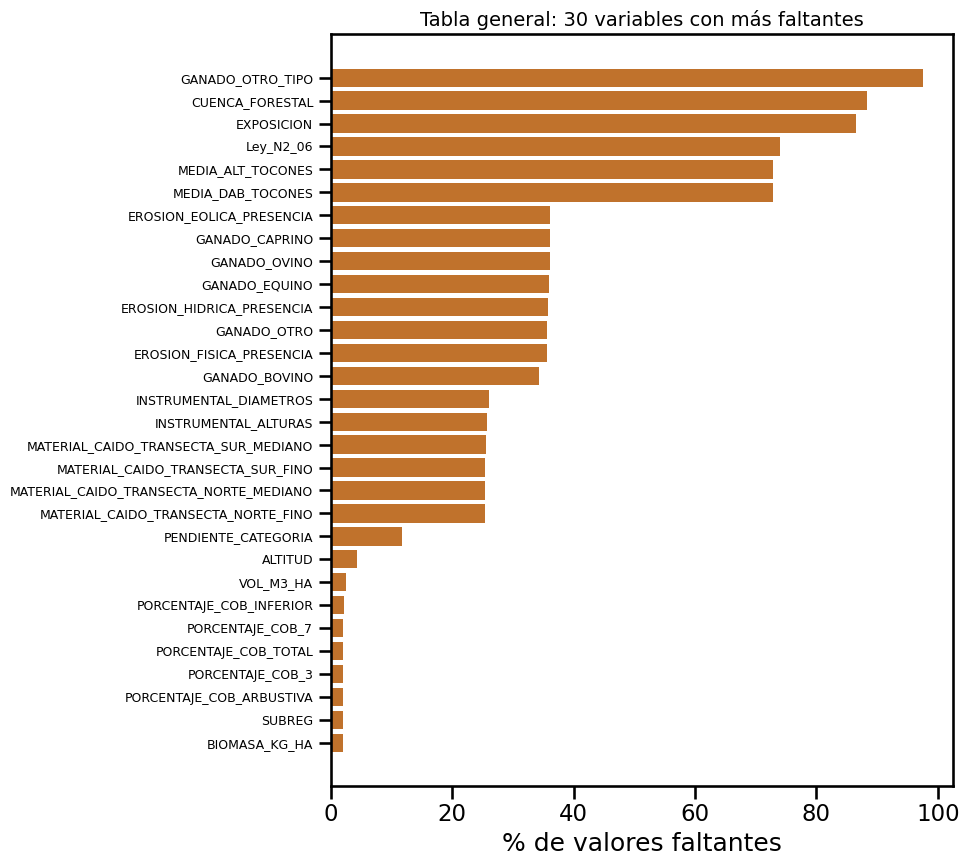

In [ ]:
faltantes_inicial = pd.DataFrame({
    'nulos': df_um.isnull().sum(),
    '% nulos': (df_um.isnull().mean() * 100).round(1)
})
faltantes_inicial = faltantes_inicial[faltantes_inicial['nulos'] > 0].sort_values('% nulos', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top = faltantes_inicial.head(30).sort_values('% nulos')
ax.barh(top.index, top['% nulos'], color='#c0722c')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Tabla general: 30 variables con más faltantes', fontsize=14)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

#### 2.4.1. Las 76 UM sin individuos inventariables

Es el caso que más faltantes explica y el que mejor muestra por qué no conviene aplicar una regla automática.

In [ ]:
um_sin_individuos = set(df_um['UM_ID_UM']) - set(df_ind['UM_ID_UM'])
mask_sin_ind = df_um['UM_ID_UM'].isin(um_sin_individuos)

print(f"UM sin individuos: {len(um_sin_individuos)}")
print(df_um.loc[mask_sin_ind, 'PRESENTA_IND_INVENTARIABLE'].value_counts().to_string())

cols_estructura = ['BIOMASA_TN_HA', 'CARBONO_TN_HA', 'VOL_M3_HA', 'AREA_BASAL_UM_HA',
                   'CANTIDAD_IND_VIVOS_UM', 'CANTIDAD_IND_VIVOS_HA', 'SUMA_DAP_X_UM',
                   'MEDIA_ALTURA_UM_EST', 'PORCENTAJE_COB_TOTAL', 'SUBREG', 'Ley_N1_06']
resumen = pd.DataFrame({
    'nulos totales': [df_um[c].isnull().sum() for c in cols_estructura],
    'nulos en las 76 UM': [df_um.loc[mask_sin_ind, c].isnull().sum() for c in cols_estructura],
}, index=cols_estructura)
resumen['% explicado'] = (resumen['nulos en las 76 UM'] / resumen['nulos totales'] * 100).round(1)
resumen

UM sin individuos: 76
PRESENTA_IND_INVENTARIABLE
NO    76


,nulos totales,nulos en las 76 UM,% explicado
BIOMASA_TN_HA,76,76,100.0
CARBONO_TN_HA,76,76,100.0
VOL_M3_HA,96,76,79.2
AREA_BASAL_UM_HA,76,76,100.0
CANTIDAD_IND_VIVOS_UM,76,76,100.0
CANTIDAD_IND_VIVOS_HA,76,76,100.0
SUMA_DAP_X_UM,76,76,100.0
MEDIA_ALTURA_UM_EST,76,76,100.0
PORCENTAJE_COB_TOTAL,80,76,95.0
SUBREG,77,76,98.7


Estas 76 parcelas explican prácticamente todos los faltantes de las variables estructurales. Son bosque relevado
donde no había ningún individuo leñoso inventariable (`PRESENTA_IND_INVENTARIABLE = 'NO'`), y ahí conviene
separar dos situaciones que el TP1 trataba juntas:

- Variables que son **sumas o conteos**: biomasa, carbono, volumen, área basal, cantidad de individuos, suma de
  DAP. Si no hay individuos, el valor correcto **es 0**, no "desconocido". Dejarlas como `NaN` haría que
  cualquier promedio regional las ignore y sobreestime la biomasa media al excluir del cálculo las parcelas sin individuos inventariables.
- Variables que son **promedios**: `MEDIA_ALTURA_UM_EST`. El promedio de un conjunto vacío no es 0, es
  indefinido. Se dejan como `NaN`.

La distinción importa para el objetivo del proyecto: una parcela sin individuos inventariables no es simplemente un dato faltante, sino que aporta información relevante sobre la estructura registrada en esa unidad de muestreo.

In [ ]:
cols_a_cero = ['BIOMASA_TN_HA', 'CARBONO_TN_HA', 'BIOMASA_KG_HA', 'CARBONO_KG_HA', 'VOL_M3_HA',
               'AREA_BASAL_UM_HA', 'CANTIDAD_IND_VIVOS_UM', 'CANTIDAD_IND_VIVOS_HA', 'SUMA_DAP_X_UM']
cols_a_cero = [c for c in cols_a_cero if c in df_um.columns]

for c in cols_a_cero:
    df_um.loc[mask_sin_ind & df_um[c].isnull(), c] = 0

df_um['SIN_IND_INVENTARIABLE'] = mask_sin_ind.astype(int)

print("Nulos remanentes en variables estructurales:")
print(df_um[cols_a_cero + ['MEDIA_ALTURA_UM_EST']].isnull().sum().to_string())

Nulos remanentes en variables estructurales:
BIOMASA_TN_HA             0
CARBONO_TN_HA             0
BIOMASA_KG_HA             0
CARBONO_KG_HA             0
VOL_M3_HA                20
AREA_BASAL_UM_HA          0
CANTIDAD_IND_VIVOS_UM     0
CANTIDAD_IND_VIVOS_HA     0
SUMA_DAP_X_UM             0
MEDIA_ALTURA_UM_EST      76


#### 2.4.2. Nulos estructurales: recodificación con bandera

Los casos 1, 3, 4, 5 y 7 del TP1 son todos "no aplica": no hay otro tipo de ganado, no hay tocones que medir, el
terreno es plano y no tiene exposición, la UM no pertenece a una cuenca prioritaria, el individuo es arbustivo y
no tiene fuste único. La estrategia es la misma en todos: **una bandera binaria que registra si el caso aplica,
más la recodificación del valor**.

In [ ]:
# Tocones: si no hay tocones, la media de altura/diámetro no aplica
df_um['TIENE_TOCONES'] = (df_um['CANTIDAD_TOCONES_X_UM'].fillna(0) > 0).astype(int)

# La exposición no aplica cuando el terreno está registrado sin pendiente
sin_pendiente = df_um['PENDIENTE_CATEGORIA'] == 'sin_pendiente'

df_um.loc[
    df_um['EXPOSICION'].isna() & sin_pendiente,
    'EXPOSICION'
] = 'sin_exposicion'

# Si tampoco se informó la pendiente, interpretamos que el bloque no fue relevado
df_um.loc[
    df_um['EXPOSICION'].isna() & df_um['PENDIENTE_CATEGORIA'].isna(),
    'EXPOSICION'
] = 'sin_dato'

# Si existe pendiente pero falta la exposición, también queda como dato desconocido
df_um['EXPOSICION'] = df_um['EXPOSICION'].fillna('sin_dato')

print(df_um['EXPOSICION'].value_counts(dropna=False))

# Cuenca forestal: la UM pertenece o no a una cuenca prioritaria
df_um['EN_CUENCA_PRIORITARIA'] = df_um['CUENCA_FORESTAL'].notnull().astype(int)
df_um['CUENCA_FORESTAL'] = df_um['CUENCA_FORESTAL'].fillna('sin_cuenca')

# Otro ganado: el tipo sólo se especifica si se detectó otro ganado
df_um['GANADO_OTRO_TIPO'] = df_um['GANADO_OTRO_TIPO'].fillna('no_aplica')

# Individuos arbustivos: DAP = 0 significa sin fuste único medible
df_ind['ES_ARBUSTIVO'] = (df_ind['DAP_CM'] == 0).astype(int)

print(f"UM con tocones: {df_um['TIENE_TOCONES'].sum()} ({df_um['TIENE_TOCONES'].mean()*100:.1f}%)")
print(f"UM en cuenca prioritaria: {df_um['EN_CUENCA_PRIORITARIA'].sum()} "
      f"({df_um['EN_CUENCA_PRIORITARIA'].mean()*100:.1f}%)")
print(f"Individuos arbustivos (DAP = 0): {df_ind['ES_ARBUSTIVO'].sum()} "
      f"({df_ind['ES_ARBUSTIVO'].mean()*100:.2f}%)")

EXPOSICION
sin_exposicion    2868
sin_dato           499
SE                  82
O                   74
E                   72
N                   72
S                   71
NE                  63
SO                  53
NO                  37
Name: count, dtype: int64
UM con tocones: 1054 (27.1%)
UM en cuenca prioritaria: 457 (11.7%)
Individuos arbustivos (DAP = 0): 981 (0.97%)


`MEDIA_ALT_TOCONES` y `MEDIA_DAB_TOCONES` se mantienen como `NaN` en las UM sin tocones: son promedios, y vale
el mismo argumento que para la altura media de una parcela vacía. La bandera `TIENE_TOCONES` conserva la
información de que ese nulo es un "no aplica" y no un dato perdido, que es lo que se necesita para que cualquier
modelo posterior no interprete mal la ausencia.

#### 2.4.3. Volumen faltante a nivel individuo

El TP1 había clasificado los 987 nulos de `VOL_M3` como "residuales, sin patrón sistemático evidente". Revisando
con más detalle, sí hay patrón.

In [ ]:
sin_volumen = df_ind['VOL_M3'].isnull()
print(f"Individuos sin VOL_M3: {sin_volumen.sum()}")
print(f"  de los cuales tienen DAP = 0: {(sin_volumen & (df_ind['DAP_CM'] == 0)).sum()}")
print("\nRegión de los individuos sin volumen:")
print(df_ind.loc[sin_volumen, 'REGION_OFC'].value_counts().to_string())

Individuos sin VOL_M3: 987
  de los cuales tienen DAP = 0: 981

Región de los individuos sin volumen:
REGION_OFC
MON    987


Los 987 casos están **todos** en el Monte (MON) y 981 de ellos tienen `DAP_CM = 0`. Son exactamente los mismos
individuos arbustivos del caso 7 del TP1: sin fuste único no hay diámetro, y sin diámetro no hay fórmula de
volumen. No es un faltante residual sino otro nulo estructural, y corregir esa clasificación importa porque
cambia la decisión: no se imputa.

Quedan 6 individuos con DAP mayor a cero y sin volumen. Para esos se imputa con la fórmula dasométrica
$V = AB \cdot h \cdot ff$, usando como factor de forma ($ff$) la mediana de la región, que se puede estimar
desde los individuos que sí tienen las tres variables.

In [ ]:
factor_forma = df_ind['VOL_M3'] / (df_ind['AREA_BASAL_M2'] * df_ind['ALTURA_M'])
ff_region = factor_forma[df_ind['DAP_CM'] > 0].groupby(df_ind['REGION_OFC']).median()
print("Factor de forma mediano por región:")
print(ff_region.round(3).to_string())

a_imputar = sin_volumen & (df_ind['DAP_CM'] > 0)
df_ind.loc[a_imputar, 'VOL_M3'] = (df_ind.loc[a_imputar, 'AREA_BASAL_M2']
                                   * df_ind.loc[a_imputar, 'ALTURA_M']
                                   * df_ind.loc[a_imputar, 'REGION_OFC'].map(ff_region))
print(f"\nIndividuos con volumen imputado: {a_imputar.sum()}")
print(f"Nulos remanentes en VOL_M3: {df_ind['VOL_M3'].isnull().sum()} (todos arbustivos, se conservan como NaN)")

# El mismo problema se propaga a la tabla general: quedan 20 UM con individuos pero sin VOL_M3_HA
um_sin_vol = df_um['VOL_M3_HA'].isnull() & df_um['UM_ID_UM'].isin(df_ind['UM_ID_UM'])
print(f"\nUM con individuos y VOL_M3_HA nulo: {um_sin_vol.sum()} "
      f"(regiones: {df_um.loc[um_sin_vol, 'REGION_OFC'].unique()})")

vol_recalculado = (df_ind.assign(_v=df_ind['VOL_M3'].fillna(0) * df_ind['FACTOR_EXPANSION'])
                   .groupby('UM_ID_UM')['_v'].sum())
df_um.loc[um_sin_vol, 'VOL_M3_HA'] = df_um.loc[um_sin_vol, 'UM_ID_UM'].map(vol_recalculado).round(2)
print(f"Nulos remanentes en VOL_M3_HA: {df_um['VOL_M3_HA'].isnull().sum()}")

Factor de forma mediano por región:
REGION_OFC
BAP    0.554
DEL    0.927
ESP    0.995
MON    0.414
PCH    0.578
SMI    0.499
STB    0.568

Individuos con volumen imputado: 6
Nulos remanentes en VOL_M3: 981 (todos arbustivos, se conservan como NaN)

UM con individuos y VOL_M3_HA nulo: 20 (regiones: ['MON'])
Nulos remanentes en VOL_M3_HA: 0


#### 2.4.4. Nulos genuinos: imputación

Quedan tres variables con faltantes que no responden a un "no aplica" ni a un cambio de protocolo, y que se usan
en el análisis: `ALTITUD`, `SUBREG` y `PENDIENTE_CATEGORIA`.

**`SUBREG`** no requiere imputación estadística: el valor no es desconocido, está en otra parte de los datos.
Se resuelve en dos pasos determinísticos. Primero, los 5.136 individuos sin subregión (todos del Bosque
Tucumano-Boliviano, donde la columna quedó vacía en la tabla de individuos) heredan la subregión de su unidad de
muestreo, que sí la tiene. Segundo, las regiones forestales con una única subregión permiten completar el resto
sin ambigüedad.

In [ ]:
print("Nulos en SUBREG antes de imputar:")
print(f"  tabla general   : {df_um['SUBREG'].isnull().sum()}")
print(f"  tabla individuos: {df_ind['SUBREG'].isnull().sum()}")

# 1) Cada individuo pertenece a una UM, y la UM tiene subregión: se propaga por UM_ID_UM
mapa_um = df_um.set_index('UM_ID_UM')['SUBREG']
falta_ind = df_ind['SUBREG'].isnull()
df_ind.loc[falta_ind, 'SUBREG'] = df_ind.loc[falta_ind, 'UM_ID_UM'].map(mapa_um)

# 2) Las regiones con una sola subregión permiten completar el resto sin ambigüedad
subreg_por_region = df_um.groupby('REGION_OFC')['SUBREG'].nunique()
print("\nSubregiones distintas por región (tabla general):")
print(subreg_por_region.to_string())

regiones_univocas = subreg_por_region[subreg_por_region == 1].index
mapa_subreg = (df_um[df_um['REGION_OFC'].isin(regiones_univocas)]
               .groupby('REGION_OFC')['SUBREG'].first())

for df_tmp in (df_um, df_ind):
    falta = df_tmp['SUBREG'].isnull() & df_tmp['REGION_OFC'].isin(regiones_univocas)
    df_tmp.loc[falta, 'SUBREG'] = df_tmp.loc[falta, 'REGION_OFC'].map(mapa_subreg)

print("\nNulos en SUBREG después de la imputación determinística:")
print(f"  tabla general   : {df_um['SUBREG'].isnull().sum()}")
print(f"  tabla individuos: {df_ind['SUBREG'].isnull().sum()}")

Nulos en SUBREG antes de imputar:
  tabla general   : 77
  tabla individuos: 5136

Subregiones distintas por región (tabla general):
REGION_OFC
BAP    1
DEL    2
ESP    3
MON    1
PCH    5
SMI    1
STB    3

Nulos en SUBREG después de la imputación determinística:
  tabla general   : 60
  tabla individuos: 21


In [ ]:
# Lo que queda sin resolver se marca como categoría explícita
for df_tmp in (df_um, df_ind):
    df_tmp['SUBREG'] = df_tmp['SUBREG'].fillna('sin_subregion')

**`ALTITUD`** (47 nulos originales + 122 ceros recodificados = 169 casos, 4,3%) se imputa aprovechando las
coordenadas recuperadas en 2.3.3: la altitud es una variable fuertemente autocorrelacionada en el espacio, así
que el vecino geográfico es un predictor mucho mejor que la media regional. Se usa KNN con k=5 sobre latitud y
longitud.

In [ ]:
completos = df_um['ALTITUD'].notnull() & df_um['LATITUD'].notnull() & df_um['LONGITUD'].notnull()
faltan = df_um['ALTITUD'].isnull() & df_um['LATITUD'].notnull() & df_um['LONGITUD'].notnull()

# Control de calidad del método: validación cruzada sobre las UM con altitud conocida,
# comparando contra la alternativa simple (imputar la media)
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.dummy import DummyRegressor

X_alt = df_um.loc[completos, ['LATITUD', 'LONGITUD']]
y_alt = df_um.loc[completos, 'ALTITUD']

knn = KNeighborsRegressor(n_neighbors=5, weights='distance')
r2_knn = cross_val_score(knn, X_alt, y_alt, cv=5, scoring='r2').mean()
r2_base = cross_val_score(DummyRegressor(strategy='mean'), X_alt, y_alt, cv=5, scoring='r2').mean()
pred = cross_val_predict(knn, X_alt, y_alt, cv=5)
error_abs = np.abs(pred - y_alt)

print(f"R² KNN espacial      : {r2_knn:.3f}")
print(f"R² imputar la media  : {r2_base:.3f}")
print(f"Error absoluto mediano del KNN: {np.median(error_abs):.0f} m")
print(f"  restringido al Parque Chaqueño, de donde viene el 96% de los casos a imputar: "
      f"{np.median(error_abs[df_um.loc[completos, 'REGION_OFC'] == 'PCH']):.0f} m")

knn.fit(df_um.loc[completos, ['LATITUD', 'LONGITUD']], df_um.loc[completos, 'ALTITUD'])
df_um['ALTITUD_IMPUTADA'] = faltan.astype(int)
df_um.loc[faltan, 'ALTITUD'] = knn.predict(df_um.loc[faltan, ['LATITUD', 'LONGITUD']]).round(0)

print(f"\nUM con altitud imputada: {int(df_um['ALTITUD_IMPUTADA'].sum())}")
print(f"Nulos remanentes en ALTITUD: {df_um['ALTITUD'].isnull().sum()}")

R² KNN espacial      : 0.593
R² imputar la media  : -0.284
Error absoluto mediano del KNN: 34 m
  restringido al Parque Chaqueño, de donde viene el 96% de los casos a imputar: 19 m

UM con altitud imputada: 168
Nulos remanentes en ALTITUD: 1


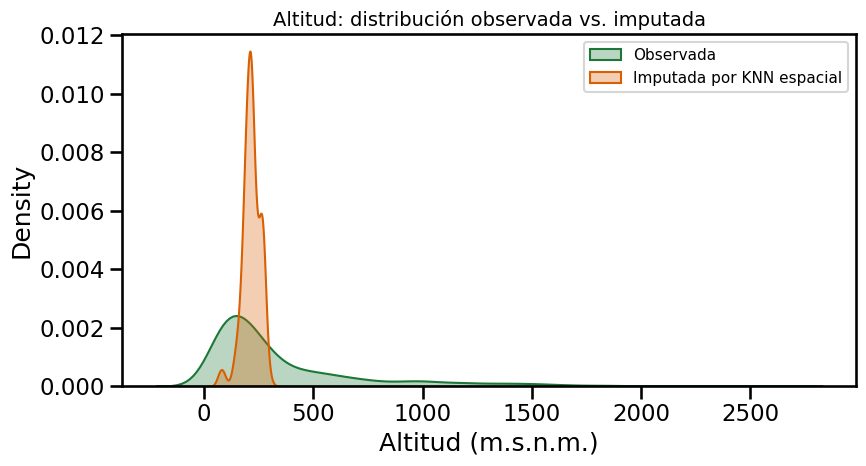

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(df_um.loc[df_um['ALTITUD_IMPUTADA'] == 0, 'ALTITUD'], ax=ax,
            label='Observada', fill=True, alpha=0.3, color='#1b7837')
sns.kdeplot(df_um.loc[df_um['ALTITUD_IMPUTADA'] == 1, 'ALTITUD'], ax=ax,
            label='Imputada por KNN espacial', fill=True, alpha=0.3, color='#d95f02')
ax.set_xlabel('Altitud (m.s.n.m.)')
ax.set_title('Altitud: distribución observada vs. imputada', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

El R² de 0,59 no es espectacular en términos absolutos, y conviene ser honestos al respecto: la altitud varía
mucho en distancias cortas en las regiones de montaña, y ahí el vecino más cercano no alcanza. Lo que importa
para esta decisión, sin embargo, es otra cosa. Primero, la comparación relevante no es contra un modelo
perfecto sino contra la alternativa realista, que era imputar la media (R² negativo, es decir peor que no hacer
nada). Segundo, el error absoluto mediano cae a unos 20 m cuando se lo mide en el Parque Chaqueño, que es de
donde proviene prácticamente la totalidad de los casos a imputar: sobre una variable que en esa región va de 10
a 1.800 m.s.n.m., es un error aceptable. La bandera `ALTITUD_IMPUTADA` queda de todos modos en el dataset para
que cualquier análisis sensible pueda excluir esos casos.

La distribución de los valores imputados se concentra en el rango bajo, coherente con su origen chaqueño.

**`PENDIENTE_CATEGORIA`** presenta 459 valores faltantes (11,8%). En esos mismos casos tampoco se registró la exposición, lo que indica que el bloque de relieve no fue completado. Por este motivo, no se imputó la categoría más frecuente, ya que eso implicaría asumir que el terreno es plano sin contar con evidencia.

Para conservar esta diferencia, los faltantes de pendiente se recodificaron como `sin_dato`. En `EXPOSICION` se utilizó `sin_exposicion` únicamente cuando la parcela estaba registrada explícitamente como `sin_pendiente`. Cuando faltaban ambas variables, la exposición se recodificó como `sin_dato`.

In [ ]:
print(pd.crosstab(df_um['PENDIENTE_CATEGORIA'].isnull(), df_um['EXPOSICION'] == 'sin_exposicion',
                  rownames=['PENDIENTE nula'], colnames=['EXPOSICION no registrada']))

df_um['PENDIENTE_CATEGORIA'] = df_um['PENDIENTE_CATEGORIA'].fillna('sin_dato')
df_um['OTBN_CATEGORIA'] = df_um['OTBN_CATEGORIA'].fillna('sin_categoria')

EXPOSICION no registrada  False  True 
PENDIENTE nula                        
False                       564   2868
True                        459      0


#### 2.4.5. Nulos por cobertura temporal

Las variables de ganado y erosión se incorporaron al protocolo en 2018-2019 (caso 2 del TP1). Se conservan sin
imputar y se agrega una variable que identifica explícitamente el período con relevamiento válido, para que
cualquier análisis posterior pueda filtrar sin tener que redescubrir el problema.

In [ ]:
cols_protocolo_nuevo = ['GANADO_BOVINO', 'GANADO_OVINO', 'GANADO_CAPRINO', 'GANADO_EQUINO', 'GANADO_OTRO',
                        'EROSION_FISICA_PRESENCIA', 'EROSION_EOLICA_PRESENCIA', 'EROSION_HIDRICA_PRESENCIA']

nulos_por_anio = (df_um.groupby('FECHA_UM_ANIO')[cols_protocolo_nuevo]
                  .apply(lambda s: s.isnull().mean().mean() * 100).round(1))
print("% de nulos promedio en el bloque ganado/erosión, por año:")
print(nulos_por_anio.to_string())

df_um['PROTOCOLO_COMPLETO'] = (df_um['FECHA_UM_ANIO'] >= 2018).astype(int)
print(f"\nUM con protocolo completo (>= 2018): {df_um['PROTOCOLO_COMPLETO'].sum()} "
      f"({df_um['PROTOCOLO_COMPLETO'].mean()*100:.1f}%)")

% de nulos promedio en el bloque ganado/erosión, por año:
FECHA_UM_ANIO
2015.0    99.8
2016.0    96.3
2017.0    99.9
2018.0    27.9
2019.0     0.0
2020.0     0.0

UM con protocolo completo (>= 2018): 2845 (73.1%)


#### 2.4.6. Estado de los faltantes después de la curación

In [ ]:
def comparar_faltantes(antes, despues, nombre):
    return pd.Series({
        'columnas con nulos (antes)': int((antes.isnull().sum() > 0).sum()),
        'columnas con nulos (después)': int((despues.isnull().sum() > 0).sum()),
        '% celdas nulas (antes)': round(antes.isnull().sum().sum() / antes.size * 100, 2),
        '% celdas nulas (después)': round(despues.isnull().sum().sum() / despues.size * 100, 2),
    }, name=nombre)

pd.concat([comparar_faltantes(df_um_crudo, df_um, 'Tabla general'),
           comparar_faltantes(df_ind_crudo, df_ind, 'Tabla individuos')], axis=1)

,Tabla general,Tabla individuos
columnas con nulos (antes),72.00,10.00
columnas con nulos (después),59.00,10.00
% celdas nulas (antes),12.59,18.61
% celdas nulas (después),7.96,15.88


**Resumen de decisiones sobre faltantes**

| Variable(s) | % nulos original | Tipo de nulo | Acción aplicada |
|---|---|---|---|
| Biomasa, carbono, volumen, área basal, conteos (76 UM) | 2,0% | Estructural (sin individuos) | Imputación con **0**, más bandera `SIN_IND_INVENTARIABLE` |
| `MEDIA_ALTURA_UM_EST` (76 UM) | 2,0% | Estructural (promedio indefinido) | Se conserva `NaN` |
| `MEDIA_ALT/DAB_TOCONES` | 72,9% | Estructural (sin tocones) | Se conserva `NaN`, más bandera `TIENE_TOCONES` |  `EXPOSICION` | 86,5% | Estructural si no hay pendiente / no relevado si falta el bloque | `sin_exposicion` cuando no hay pendiente y `sin_dato` cuando falta información |
| `CUENCA_FORESTAL` | 88,3% | Estructural (fuera de cuenca) | Recodificada a `sin_cuenca`, más bandera `EN_CUENCA_PRIORITARIA` |
| `GANADO_OTRO_TIPO` | 97,6% | Estructural | Recodificada a `no_aplica` |
| `VOL_M3` individuos arbustivos | 1,0% | Estructural (sin fuste) | Se conserva `NaN`, más bandera `ES_ARBUSTIVO` |
| `VOL_M3` (6 casos con DAP > 0) | <0,01% | Genuino | Imputado con $V = AB \cdot h \cdot ff$ regional |
| `ALTURA_TOTAL_M` (3 casos) | <0,01% | Genuino | Resuelto usando `ALTURA_TOTAL_EST` |
| `ALTITUD` (47 nulos + 122 ceros) | 4,3% | Genuino / error de carga | Imputada por **KNN espacial** sobre coordenadas |
| `SUBREG` | 2,0% | Genuino | Imputación determinística por región; resto a `sin_subregion` |
| `PENDIENTE_CATEGORIA` | 11,8% | Bloque de relieve no relevado | Recodificada como `sin_dato`; no se imputa la moda |
| `GANADO_*`, `EROSION_*` | 34-36% | Cobertura temporal | Se conservan; bandera `PROTOCOLO_COMPLETO` |
| `Ley_N2_06` | 74,0% | Cobertura incompleta | Se descarta (sección 2.5) |
| Columnas administrativas | 25-26% | Irrelevante para el objetivo | Se descartan (sección 2.5) |

No se eliminó ninguna fila por valores faltantes en ninguna de las dos tablas.

### 2.5. Selección de variables

La tabla general tiene 78 columnas originales y no todas aportan al objetivo del proyecto (caracterizar la
estructura y el estado del bosque nativo). Se descartan tres tipos de columnas, con criterios distintos:

1. **Redundantes por construcción**: variables que son una transformación exacta de otra. Mantenerlas duplica
   información, infla artificialmente las correlaciones y, en un modelo, genera colinealidad perfecta.
2. **Administrativas / de proceso**: describen cómo se hizo el relevamiento, no el bosque.
3. **Sin cobertura suficiente y sin uso previsto**.

Antes de descartar por redundancia se verifica numéricamente que la relación sea exacta y no aproximada.

In [ ]:
def verificar_redundancia(df, col_a, col_b, factor_esperado, etiqueta):
    """Comprueba si col_a = factor * col_b sobre las filas donde ambas están informadas."""
    valido = df[col_a].notnull() & df[col_b].notnull() & (df[col_b] != 0)
    ratio = (df.loc[valido, col_a] / df.loc[valido, col_b])
    return {'relación': etiqueta, 'n comparado': int(valido.sum()),
            'ratio mediano': round(ratio.median(), 4),
            'coincide con lo esperado': bool(np.isclose(ratio.median(), factor_esperado, rtol=1e-3))}

chequeos = [
    verificar_redundancia(df_um, 'CARBONO_TN_HA', 'BIOMASA_TN_HA', 0.48, 'CARBONO = 0,48 x BIOMASA (UM)'),
    verificar_redundancia(df_um, 'BIOMASA_KG_HA', 'BIOMASA_TN_HA', 1000, 'KG/ha = 1000 x TN/ha (UM)'),
    verificar_redundancia(df_ind, 'CARBONO_KG', 'BIOMASA_KG', 0.48, 'CARBONO = 0,48 x BIOMASA (individuos)'),
    verificar_redundancia(df_ind, 'DAP_FINAL_M', 'DAP_CM', 0.01, 'DAP_FINAL_M = DAP_CM / 100'),
    verificar_redundancia(df_ind, 'DAB_FINAL_M', 'DAB_CM', 0.01, 'DAB_FINAL_M = DAB_CM / 100'),
]
pd.DataFrame(chequeos)

,relación,n comparado,ratio mediano,coincide con lo esperado
0,"CARBONO = 0,48 x BIOMASA (UM)",3815,0.48,True
1,KG/ha = 1000 x TN/ha (UM),3815,1000.00,True
2,"CARBONO = 0,48 x BIOMASA (individuos)",101229,0.48,True
3,DAP_FINAL_M = DAP_CM / 100,100248,0.01,True
4,DAB_FINAL_M = DAB_CM / 100,981,0.01,True


Las cinco relaciones son exactas. El caso del carbono es el más claro: se obtiene multiplicando la biomasa por
el factor fijo 0,48, así que las dos variables tienen correlación 1,00 por definición y no aportan información
independiente (el TP1 ya lo había señalado al ver la matriz de correlación). Se conserva la biomasa, que es la
variable medida, y el carbono se puede recuperar en cualquier momento multiplicando.

In [ ]:
descartar_um = {
    # Redundantes por construcción
    'CARBONO_TN_HA': 'Redundante: 0,48 x BIOMASA_TN_HA',
    'CARBONO_KG_HA': 'Redundante: 0,48 x BIOMASA_KG_HA',
    'BIOMASA_KG_HA': 'Redundante: 1000 x BIOMASA_TN_HA (unidad distinta)',
    'LATITUD_GRILLA': 'Reemplazada por LATITUD recuperada (2.3.3)',
    'LONGITUD_GRILLA': 'Reemplazada por LONGITUD recuperada (2.3.3)',
    'LATITUD_INSTALACION': 'Coordenada con el mismo error de escala, sin aportar precisión adicional',
    'LONGITUD_INSTALACION': 'Coordenada con el mismo error de escala, sin aportar precisión adicional',
    # Administrativas / de proceso
    'JEFE_BRIGADA': 'Administrativa: identifica al responsable del relevamiento',
    'NO_PERSONAS_BRIGADA': 'Administrativa: logística del operativo',
    'DURACION_RELEVAMIENTO_SEGUNDOS': 'Administrativa: no describe el bosque',
    'INSTRUMENTAL_DIAMETROS': 'Administrativa: instrumento utilizado',
    'INSTRUMENTAL_ALTURAS': 'Administrativa: instrumento utilizado',
    'OBSERVACIONES_UM': 'Texto libre sin estructura',
    'DATOS_REFERENCIA': 'Texto libre sin estructura',
    # Cobertura insuficiente
    'Ley_N2_06': 'Cobertura del 26% incluso en el mejor año; no utilizable como variable de agrupamiento',
}

descartar_ind = {
    'CARBONO_KG': 'Redundante: 0,48 x BIOMASA_KG',
    'DAP_FINAL_M': 'Redundante: DAP_CM / 100',
    'DAB_FINAL_M': 'Redundante: DAB_CM / 100',
    'AREABASAL_M2_ORIGINAL': 'Mal calculada (factor 100), reemplazada por AREA_BASAL_M2',
    'AREABASAL_CM2_ORIGINAL': 'Mal calculada (factor 100), reemplazada por AREA_BASAL_M2',
    'ALTURA_TOTAL_EST': 'Adoptada como ALTURA_M en 2.3.6',
    'BIOMASA_TN_HA': 'Derivable: BIOMASA_KG x FACTOR_EXPANSION / 1000',
    'CARBONO_TN_HA': 'Redundante: 0,48 x BIOMASA_TN_HA',
    'VOL_M3_HA': 'Derivable: VOL_M3 x FACTOR_EXPANSION',
    'DIAMETRO_COPA_1': 'Resumida en MEDIA_DIAM_COPA',
    'DIAMETRO_COPA_2': 'Resumida en MEDIA_DIAM_COPA',
    'Ley_N2_06': 'Cobertura insuficiente (76,6% de nulos)',
    'PROVINCIA': 'Ya presente en la tabla general; se evita duplicar al cruzar',
}

resumen_descarte = pd.concat([
    pd.Series(descartar_um, name='motivo').to_frame().assign(tabla='Tabla general'),
    pd.Series(descartar_ind, name='motivo').to_frame().assign(tabla='Tabla individuos'),
])
resumen_descarte.index.name = 'variable'
resumen_descarte[['tabla', 'motivo']]

,tabla,motivo
variable,,
CARBONO_TN_HA,Tabla general,"Redundante: 0,48 x BIOMASA_TN_HA"
CARBONO_KG_HA,Tabla general,"Redundante: 0,48 x BIOMASA_KG_HA"
BIOMASA_KG_HA,Tabla general,Redundante: 1000 x BIOMASA_TN_HA (unidad disti...
LATITUD_GRILLA,Tabla general,Reemplazada por LATITUD recuperada (2.3.3)
LONGITUD_GRILLA,Tabla general,Reemplazada por LONGITUD recuperada (2.3.3)
LATITUD_INSTALACION,Tabla general,"Coordenada con el mismo error de escala, sin a..."
LONGITUD_INSTALACION,Tabla general,"Coordenada con el mismo error de escala, sin a..."
JEFE_BRIGADA,Tabla general,Administrativa: identifica al responsable del ...
NO_PERSONAS_BRIGADA,Tabla general,Administrativa: logística del operativo


Se conservan, en cambio, variables que a primera vista podrían parecer descartables:

- **`REGENERACION_HA` y `PORCENTAJE_COB_ARBUSTIVA`**, que en el TP1 aparecían con correlación cercana a cero
  contra el resto de las dasométricas. Esa baja correlación es exactamente el motivo para conservarlas: capturan
  una dimensión del bosque (renovación y estrato bajo) que ninguna otra variable describe, y la regeneración es
  un indicador central del estado del bosque nativo.
- **`SIN_IND_INVENTARIABLE`** y las demás banderas creadas en 2.4, que preservan la información contenida en los
  nulos estructurales.
- **Las variables de ganado y erosión** pese a su 35% de nulos, porque el nulo tiene una explicación temporal
  documentada y para las UM posteriores a 2018 la información es completa.

### 2.6. Generación de nuevas variables

Se construyen variables en tres niveles: transformación de columnas existentes, indicadores derivados a nivel de
individuo y agregados a nivel de parcela calculados desde la tabla de individuos.

#### 2.6.1. Decodificación de variables mal tipadas

`PROVINCIA` viene como código numérico del INDEC. Almacenada como número, cualquier análisis la trataría como
variable continua y calcularía cosas sin sentido (una "provincia media" de 47,3). Se decodifica a nombre y se
la trata como categórica.

In [ ]:
PROVINCIAS_INDEC = {
    2: 'CABA', 6: 'Buenos Aires', 10: 'Catamarca', 14: 'Córdoba', 18: 'Corrientes', 22: 'Chaco',
    26: 'Chubut', 30: 'Entre Ríos', 34: 'Formosa', 38: 'Jujuy', 42: 'La Pampa', 46: 'La Rioja',
    50: 'Mendoza', 54: 'Misiones', 58: 'Neuquén', 62: 'Río Negro', 66: 'Salta', 70: 'San Juan',
    74: 'San Luis', 78: 'Santa Cruz', 82: 'Santa Fe', 86: 'Santiago del Estero', 90: 'Tucumán',
    94: 'Tierra del Fuego',
}
df_um['PROVINCIA_NOMBRE'] = pd.to_numeric(df_um['PROVINCIA'], errors='coerce').map(PROVINCIAS_INDEC)
print(f"UM sin provincia decodificada: {df_um['PROVINCIA_NOMBRE'].isnull().sum()}")
print(df_um['PROVINCIA_NOMBRE'].value_counts().head(8).to_string())

UM sin provincia decodificada: 1
PROVINCIA_NOMBRE
Santiago del Estero    649
Salta                  644
Chaco                  558
Formosa                453
La Rioja               206
Santa Fe               162
Misiones               160
San Luis               138


#### 2.6.2. Variables derivadas a nivel de individuo

In [ ]:
# Coeficiente de esbeltez: relación altura/diámetro, indicador clásico de estabilidad del árbol
df_ind['ESBELTEZ'] = np.where(df_ind['DAP_CM'] > 0,
                              df_ind['ALTURA_M'] * 100 / df_ind['DAP_CM'].replace(0, np.nan),
                              np.nan)

# Individuos de gran porte: umbral habitual para "árbol maduro" en inventarios forestales
df_ind['ES_GRANDE'] = (df_ind['DAP_CM'] >= 40).astype(int)

# Clase diamétrica como variable ordinal (conserva el orden natural, a diferencia del texto)
orden_clases = ['[5-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)',
                '[70-80)', '[80-90)', '[90-100)', '[100-110)', '[110-120)', '>=120']
df_ind['CLASE_DIAM_ORD'] = pd.Categorical(df_ind['CLASE_DIAM'], categories=orden_clases,
                                          ordered=True).codes
df_ind['CLASE_DIAM_ORD'] = df_ind['CLASE_DIAM_ORD'].replace(-1, np.nan)

df_ind[['DAP_CM', 'ALTURA_M', 'ESBELTEZ', 'ES_GRANDE', 'CLASE_DIAM', 'CLASE_DIAM_ORD']].head()

,DAP_CM,ALTURA_M,ESBELTEZ,ES_GRANDE,CLASE_DIAM,CLASE_DIAM_ORD
0,11.838074,4.2,35.478744,0,[10-20),1
1,10.160709,4.8,47.240800,0,[10-20),1
2,8.221922,4.4,53.515468,0,[5-10),0
3,7.798718,3.5,44.879172,0,[5-10),0
4,12.165525,3.7,30.413813,0,[10-20),1


La esbeltez ($h/d \times 100$) es una variable estándar en dasometría: valores altos indican árboles finos y
altos, típicos de rodales densos con competencia por luz y mayor riesgo de vuelco; valores bajos indican árboles
gruesos y bajos, propios de sitios abiertos o xerófilos. Es informativa por sí misma y además sirve como filtro
de coherencia en la sección de atípicos, porque combina dos mediciones independientes.

#### 2.6.3. Variables de composición y diversidad a nivel de parcela

La tabla general describe la estructura del bosque (cuánta biomasa, qué altura) pero no su **composición**: no
hay ninguna variable que diga cuántas especies hay en la parcela ni si está dominada por una sola. Esa
información está en la tabla de individuos y se puede agregar.

In [ ]:
# Riqueza, diversidad de Shannon y dominancia de la especie principal
comp = (df_ind.groupby(['UM_ID_UM', 'ESPECIE_CORREGIDA']).size().rename('n').reset_index())
comp['total_um'] = comp.groupby('UM_ID_UM')['n'].transform('sum')
comp['p'] = comp['n'] / comp['total_um']
comp['aporte_shannon'] = -comp['p'] * np.log(comp['p'])

diversidad = comp.groupby('UM_ID_UM').agg(
    RIQUEZA_ESPECIES=('ESPECIE_CORREGIDA', 'nunique'),
    SHANNON=('aporte_shannon', 'sum'),
    DOMINANCIA=('p', 'max'),
).reset_index()
diversidad['SHANNON'] = diversidad['SHANNON'].round(3)
diversidad['DOMINANCIA'] = diversidad['DOMINANCIA'].round(3)

diversidad.drop(columns='UM_ID_UM').describe().round(2)

,RIQUEZA_ESPECIES,SHANNON,DOMINANCIA
count,3815.00,3815.00,3815.00
mean,6.00,1.29,0.51
std,3.53,0.65,0.24
min,1.00,0.00,0.08
25%,3.00,0.89,0.33
50%,5.00,1.35,0.46
75%,8.00,1.77,0.67
max,21.00,2.93,1.00


In [ ]:
# Estructura diamétrica y composición funcional, agregadas desde individuos
df_ind['_ab_x_dens'] = df_ind['AREA_BASAL_M2'] * df_ind['DENSIDAD_MADERA']

estructura = df_ind.groupby('UM_ID_UM').agg(
    DAP_MEDIO=('DAP_CM', 'mean'),
    DAP_MAX=('DAP_CM', 'max'),
    DAP_DESVIO=('DAP_CM', 'std'),
    ALTURA_MAX=('ALTURA_M', 'max'),
    PROP_IND_GRANDES=('ES_GRANDE', 'mean'),
    PROP_ARBUSTIVOS=('ES_ARBUSTIVO', 'mean'),
    ESBELTEZ_MEDIA=('ESBELTEZ', 'mean'),
    _ab_total=('AREA_BASAL_M2', 'sum'),
    _ab_x_dens=('_ab_x_dens', 'sum'),
).reset_index()

# Densidad de madera media de la parcela, ponderada por área basal (no por número de individuos:
# un árbol grande aporta mucho más a la biomasa que un renoval)
estructura['DENSIDAD_MADERA_PONDERADA'] = (estructura['_ab_x_dens'] / estructura['_ab_total']).round(3)
estructura = estructura.drop(columns=['_ab_x_dens', '_ab_total'])
estructura['DAP_CV'] = (estructura['DAP_DESVIO'] / estructura['DAP_MEDIO']).round(3)

df_um = df_um.merge(diversidad, on='UM_ID_UM', how='left').merge(estructura, on='UM_ID_UM', how='left')

# Las 76 UM sin individuos tienen riqueza 0, no riqueza desconocida
for c in ['RIQUEZA_ESPECIES', 'SHANNON']:
    df_um.loc[df_um['SIN_IND_INVENTARIABLE'] == 1, c] = 0

print("Nuevas variables de composición y estructura incorporadas a la tabla general:")
print(df_um[['RIQUEZA_ESPECIES', 'SHANNON', 'DOMINANCIA', 'DAP_MEDIO', 'DAP_MAX',
             'PROP_IND_GRANDES', 'DENSIDAD_MADERA_PONDERADA', 'DAP_CV']].describe().round(2).to_string())

Nuevas variables de composición y estructura incorporadas a la tabla general:
       RIQUEZA_ESPECIES  SHANNON  DOMINANCIA  DAP_MEDIO  DAP_MAX  PROP_IND_GRANDES  DENSIDAD_MADERA_PONDERADA   DAP_CV
count           3891.00  3891.00     3815.00    3815.00  3815.00           3815.00                    3809.00  3790.00
mean               5.89     1.26        0.51      19.35    45.45              0.07                       0.79     0.53
std                3.59     0.67        0.24       8.63    24.08              0.14                       0.14     0.27
min                0.00     0.00        0.08       0.00     0.00              0.00                       0.27     0.03
25%                3.00     0.84        0.33      14.40    31.10              0.00                       0.72     0.40
50%                5.00     1.33        0.46      17.17    40.20              0.02                       0.82     0.50
75%                8.00     1.76        0.67      21.60    52.90              0.08       

El coeficiente de variación del diámetro (`DAP_CV`) merece un comentario: es una forma compacta de describir la
**heterogeneidad estructural** de la parcela. Un rodal coetáneo (todos los árboles de edad y tamaño similar)
tiene CV bajo; un bosque irregular, con renovales y árboles maduros conviviendo, tiene CV alto. Como el TP1
mostró que la distribución diamétrica en J invertida es el indicador de buena regeneración, esta variable
permite evaluar ese mismo fenómeno **parcela por parcela** en lugar de a nivel país.

#### 2.6.4. Índice de presión antrópica

El dataset tiene varias señales sueltas de intervención humana: tocones (extracción de madera), rastros de
incendios, pastoreo, presencia de ganado. Cada una por separado es un indicador débil; combinadas describen el
nivel de presión sobre la parcela, que es una de las dimensiones del "estado del bosque" que busca el proyecto.

Se construye un índice simple como promedio de cuatro componentes binarias, calculado sólo con la información
disponible en cada UM (si el bloque de ganado no fue relevado, el índice se calcula con los componentes
restantes en lugar de asumir ausencia).

In [ ]:
componentes = pd.DataFrame({
    'tocones': (df_um['CANTIDAD_TOCONES_X_UM'].fillna(0) > 0).astype(float),
    'incendios': df_um['INCENDIOS_RASTROS'],
    'pastoreo': df_um['PASTOREO_PRESENCIA'],
    'ganado': df_um[['GANADO_BOVINO', 'GANADO_OVINO', 'GANADO_CAPRINO',
                     'GANADO_EQUINO']].max(axis=1),
})
df_um['PRESION_ANTROPICA'] = componentes.mean(axis=1, skipna=True).round(3)
df_um['PRESION_COMPONENTES'] = componentes.notnull().sum(axis=1)

print(df_um['PRESION_ANTROPICA'].describe().round(3).to_string())
print("\nComponentes disponibles por UM (según si el bloque ganado/erosión fue relevado):")
print(df_um['PRESION_COMPONENTES'].value_counts().sort_index().to_string())
print("\nDistribución del índice:")
print(df_um['PRESION_ANTROPICA'].value_counts().sort_index().to_string())

count    3891.000
mean        0.420
std         0.278
min         0.000
25%         0.250
50%         0.500
75%         0.667
max         1.000

Componentes disponibles por UM (según si el bloque ganado/erosión fue relevado):
PRESION_COMPONENTES
1       5
2       1
3    1322
4    2563

Distribución del índice:
PRESION_ANTROPICA
0.000     891
0.250     160
0.333     570
0.500    1183
0.667     350
0.750     623
1.000     114


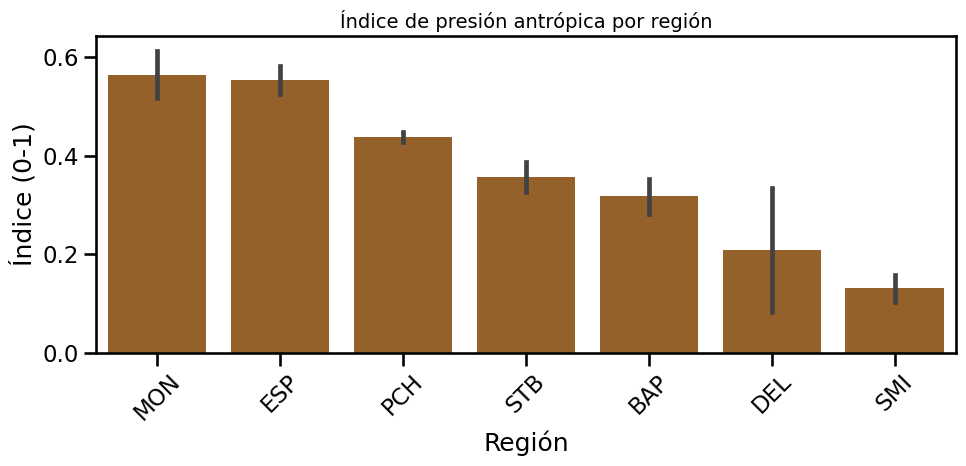

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
orden_reg = df_um.groupby('REGION_OFC')['PRESION_ANTROPICA'].mean().sort_values(ascending=False).index
sns.barplot(data=df_um, x='REGION_OFC', y='PRESION_ANTROPICA', order=orden_reg,
            errorbar=('ci', 95), color='#a6611a', ax=ax)
ax.set_title('Índice de presión antrópica por región', fontsize=14)
ax.set_xlabel('Región'); ax.set_ylabel('Índice (0-1)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### 2.6.5. Otras variables derivadas

In [ ]:
# Productos forestales no madereros: cantidad de especies registradas en lugar de 5 columnas de texto
cols_pfnm = [c for c in df_um.columns if c.startswith('PFNM_REGISTRO')]
df_um['PFNM_N_ESPECIES'] = (df_um[cols_pfnm].notnull()
                            & (df_um[cols_pfnm] != 'sin registro')).sum(axis=1)

# Riqueza de formas de vida: cuántas formas biológicas distintas se registraron en la UM
cols_formas = [c for c in df_um.columns if c.startswith('FORMAS_')]
df_um['N_FORMAS_VIDA'] = df_um[cols_formas].sum(axis=1, skipna=True)

# Biomasa por unidad de área basal: cuánta biomasa "rinde" cada m2 de sección, aproxima el porte medio
df_um['BIOMASA_POR_AB'] = (df_um['BIOMASA_TN_HA'] / df_um['AREA_BASAL_UM_HA'].replace(0, np.nan)).round(2)

# Altitud en categorías, útil para agrupar y graficar
df_um['ALTITUD_CATEGORIA'] = pd.cut(df_um['ALTITUD'], bins=[-1, 200, 500, 1000, 2000, 10000],
                                    labels=['<200', '200-500', '500-1000', '1000-2000', '>2000'])

df_um[['PFNM_N_ESPECIES', 'N_FORMAS_VIDA', 'BIOMASA_POR_AB']].describe().round(2)

,PFNM_N_ESPECIES,N_FORMAS_VIDA,BIOMASA_POR_AB
count,3891.00,3891.00,3815.00
mean,0.18,2.82,4.67
std,0.50,1.56,1.85
min,0.00,0.00,0.53
25%,0.00,2.00,3.45
50%,0.00,3.00,4.47
75%,0.00,4.00,5.58
max,5.00,7.00,16.41


In [ ]:
# Se descartan las columnas ya resumidas y las definidas en 2.5
df_um = df_um.drop(columns=[c for c in list(descartar_um) + cols_pfnm if c in df_um.columns])
df_ind = df_ind.drop(columns=[c for c in list(descartar_ind) if c in df_ind.columns])
df_ind = df_ind.drop(columns=[c for c in df_ind.columns if c.startswith('_')])

n_desc_um = len([c for c in list(descartar_um) + cols_pfnm if c in df_um_crudo.columns])
n_desc_ind = len([c for c in descartar_ind if c in df_ind_crudo.columns])
print(f"Tabla general    : {df_um_crudo.shape[1]} columnas originales - {n_desc_um} descartadas "
      f"+ nuevas = {df_um.shape[1]}")
print(f"Tabla individuos : {df_ind_crudo.shape[1]} columnas originales - {n_desc_ind} descartadas "
      f"+ nuevas = {df_ind.shape[1]}")

Tabla general    : 78 columnas originales - 20 descartadas + nuevas = 84
Tabla individuos : 31 columnas originales - 11 descartadas + nuevas = 26


#### 2.6.6. Validación de las variables generadas

Antes de darlas por buenas conviene chequear que las nuevas variables se comporten como se espera desde el
conocimiento del dominio. Si la riqueza de especies calculada desde individuos no reprodujera los patrones
regionales encontrados en el TP1, habría un error en el cálculo.

In [ ]:
validacion_nuevas = df_um.groupby('REGION_OFC').agg(
    UM=('UM_ID_UM', 'size'),
    riqueza_media=('RIQUEZA_ESPECIES', 'mean'),
    shannon_medio=('SHANNON', 'mean'),
    dominancia_media=('DOMINANCIA', 'mean'),
    dap_medio=('DAP_MEDIO', 'mean'),
    biomasa_mediana=('BIOMASA_TN_HA', 'median'),
    presion_media=('PRESION_ANTROPICA', 'mean'),
).round(2).sort_values('riqueza_media', ascending=False)
validacion_nuevas

,UM,riqueza_media,shannon_medio,dominancia_media,dap_medio,biomasa_mediana,presion_media
REGION_OFC,,,,,,,
SMI,166,10.23,2.01,0.29,27.91,119.32,0.13
PCH,2801,6.35,1.36,0.48,16.82,35.96,0.44
STB,298,5.75,1.37,0.46,28.69,90.83,0.36
DEL,18,3.89,0.85,0.67,19.25,32.00,0.21
ESP,262,3.60,0.79,0.67,18.70,26.46,0.55
MON,103,3.39,0.89,0.60,7.21,5.43,0.56
BAP,242,1.40,0.17,0.92,37.46,166.07,0.32


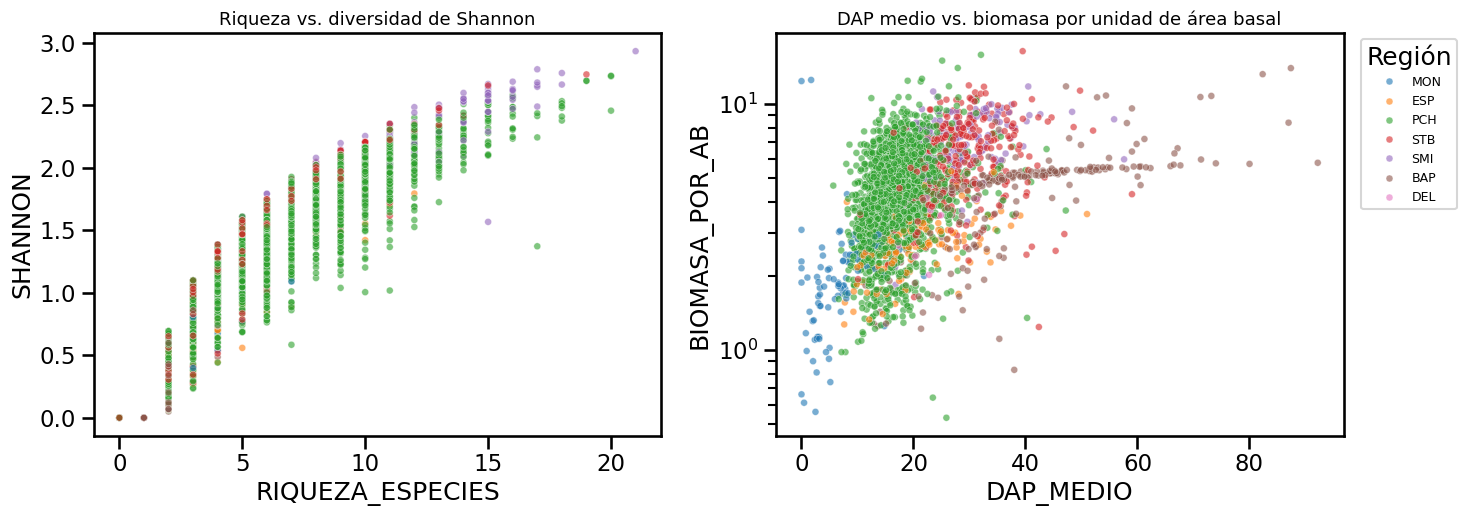

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=df_um, x='RIQUEZA_ESPECIES', y='SHANNON', hue='REGION_OFC',
                palette='tab10', s=25, alpha=0.6, ax=axes[0], legend=False)
axes[0].set_title('Riqueza vs. diversidad de Shannon', fontsize=13)

sns.scatterplot(data=df_um, x='DAP_MEDIO', y='BIOMASA_POR_AB', hue='REGION_OFC',
                palette='tab10', s=25, alpha=0.6, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('DAP medio vs. biomasa por unidad de área basal', fontsize=13)
axes[1].legend(title='Región', fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Los resultados son coherentes con lo encontrado en el TP1 por otras vías: el Parque Chaqueño encabeza la riqueza
media por parcela, mientras que el Bosque Andino Patagónico tiene riqueza baja y dominancia alta (bosques de
*Nothofagus* casi monoespecíficos) pero el mayor diámetro medio. La relación entre riqueza y Shannon tiene la
forma esperada (Shannon crece con la riqueza pero se aplana cuando una especie domina), lo que indica que ambos
índices están bien calculados.

### 2.7. Transformaciones: escalado y encoding

#### 2.7.1. Asimetría y transformación logarítmica

El TP1 ya había mostrado que las variables dasométricas son fuertemente asimétricas a derecha y había usado
escala logarítmica para poder verlas. Acá se cuantifica esa asimetría y se generan versiones transformadas.

In [ ]:
vars_dasometricas = ['BIOMASA_TN_HA', 'VOL_M3_HA', 'AREA_BASAL_UM_HA', 'CANTIDAD_IND_VIVOS_HA',
                     'REGENERACION_HA', 'CANTIDAD_TOCONES_X_HA', 'DAP_MEDIO', 'DAP_MAX',
                     'MEDIA_ALTURA_UM_EST', 'ALTITUD']
vars_dasometricas = [v for v in vars_dasometricas if v in df_um.columns]

asimetria = pd.DataFrame({
    'asimetría original': df_um[vars_dasometricas].skew().round(2),
    'asimetría con log1p': np.log1p(df_um[vars_dasometricas].clip(lower=0)).skew().round(2),
    'curtosis original': df_um[vars_dasometricas].kurtosis().round(2),
})
asimetria['mejora'] = (asimetria['asimetría original'].abs()
                       - asimetria['asimetría con log1p'].abs()).round(2)
asimetria.sort_values('asimetría original', ascending=False)

,asimetría original,asimetría con log1p,curtosis original,mejora
CANTIDAD_TOCONES_X_HA,7.45,1.30,89.03,6.15
BIOMASA_TN_HA,4.55,-0.67,37.33,3.88
VOL_M3_HA,4.48,-0.61,27.60,3.87
REGENERACION_HA,3.97,-2.62,46.46,1.35
AREA_BASAL_UM_HA,3.02,-0.25,13.00,2.77
DAP_MAX,2.54,-0.59,11.26,1.95
DAP_MEDIO,2.39,-0.76,9.93,1.63
ALTITUD,2.27,0.12,5.67,2.15
MEDIA_ALTURA_UM_EST,2.15,0.81,6.29,1.34
CANTIDAD_IND_VIVOS_HA,1.31,-2.73,2.83,-1.42


Variables que se transforman con log1p: ['BIOMASA_TN_HA', 'VOL_M3_HA', 'AREA_BASAL_UM_HA', 'REGENERACION_HA', 'CANTIDAD_TOCONES_X_HA', 'DAP_MEDIO', 'DAP_MAX', 'MEDIA_ALTURA_UM_EST', 'ALTITUD']


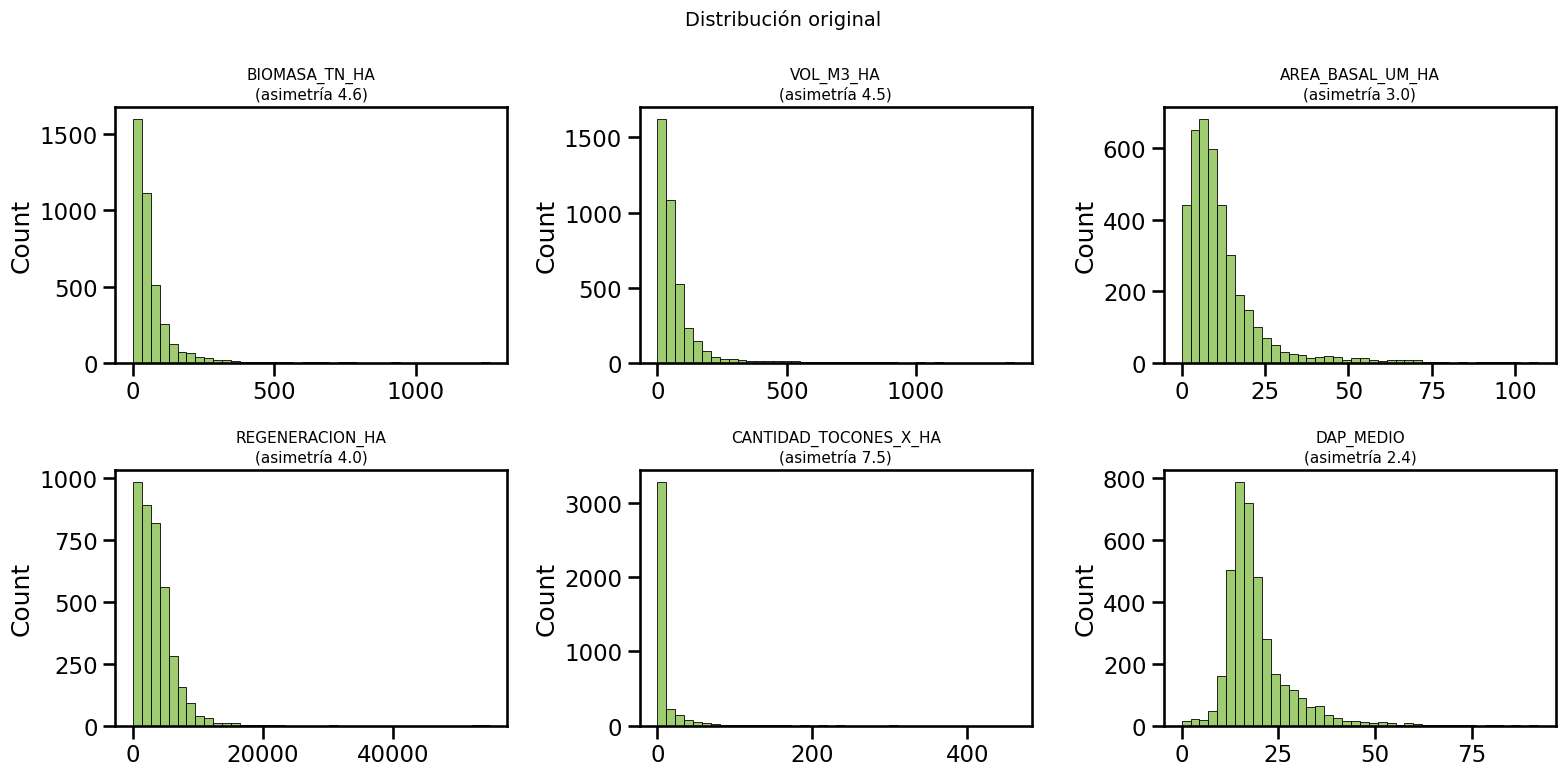

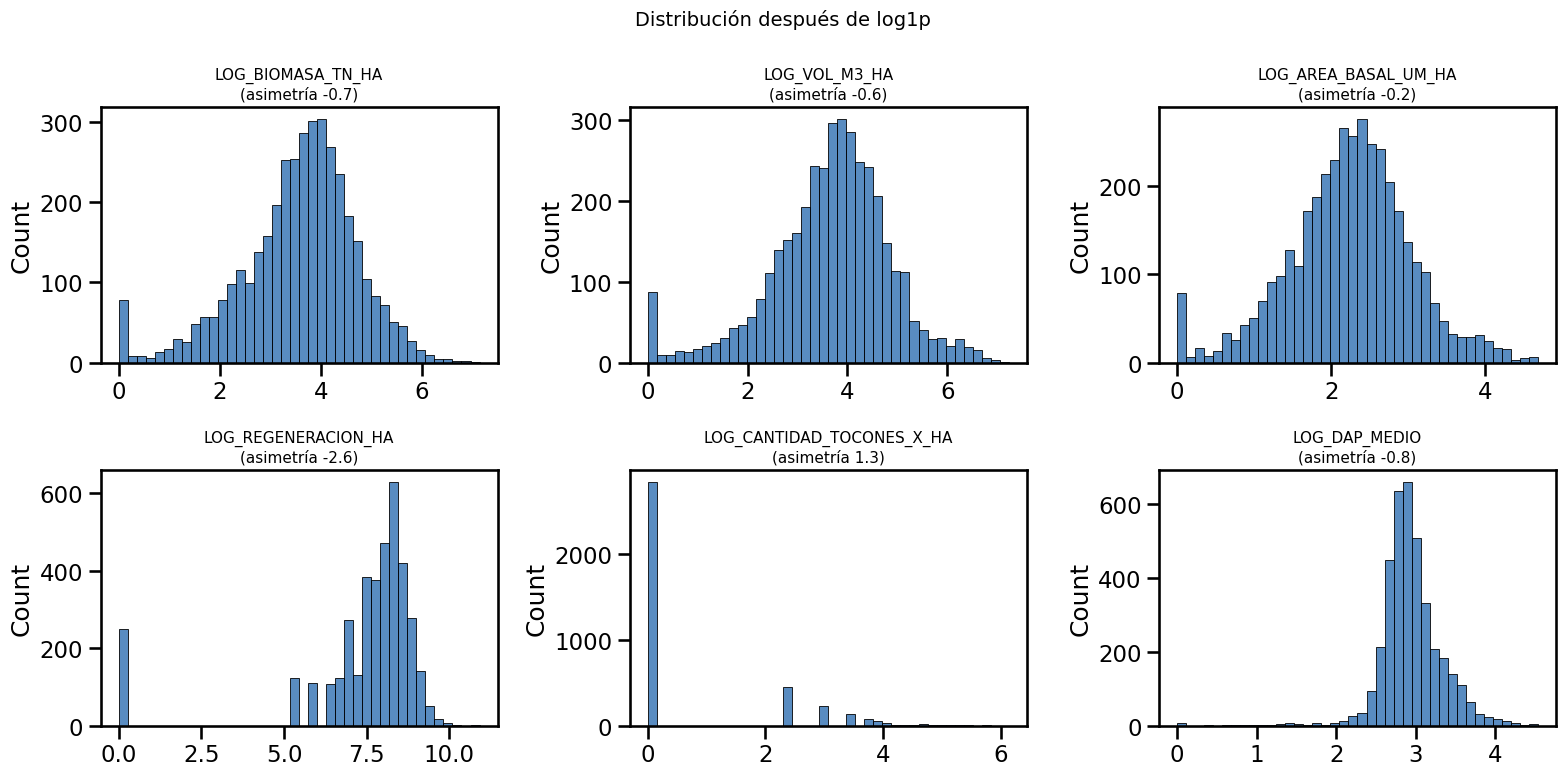

In [ ]:
vars_a_log = asimetria[(asimetria['asimetría original'] > 1) & (asimetria['mejora'] > 0)].index.tolist()
print("Variables que se transforman con log1p:", vars_a_log)

for c in vars_a_log:
    df_um[f'LOG_{c}'] = np.log1p(df_um[c].clip(lower=0))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flatten(), vars_a_log[:6]):
    sns.histplot(df_um[c].dropna(), bins=40, ax=ax, color='#7fbc41')
    ax.set_title(f'{c}\n(asimetría {df_um[c].skew():.1f})', fontsize=11)
    ax.set_xlabel('')
plt.suptitle('Distribución original', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flatten(), vars_a_log[:6]):
    sns.histplot(df_um[f'LOG_{c}'].dropna(), bins=40, ax=ax, color='#2166ac')
    ax.set_title(f'LOG_{c}\n(asimetría {df_um[f"LOG_{c}"].skew():.1f})', fontsize=11)
    ax.set_xlabel('')
plt.suptitle('Distribución después de log1p', fontsize=14)
plt.tight_layout()
plt.show()

Se usa `log1p` y no `log` porque hay ceros legítimos (las parcelas sin individuos inventariables, la
regeneración nula, las UM sin tocones): $\log(1+x)$ está definido en 0 y no obliga a descartar esas filas ni a
sumar una constante arbitraria.

Un caso merece advertencia: `REGENERACION_HA` pasa de una asimetría de +4,0 a una de −2,6. La transformación
reduce la asimetría en valor absoluto, pero la invierte, porque la variable tiene muchísimos ceros (parcelas sin
regeneración) que el logaritmo apila en un pico en el origen. Para esa variable en particular la versión
logarítmica no es obviamente mejor que la original, y probablemente convenga tratarla en dos partes (hay o no
hay regeneración, y cuánta cuando la hay). Se genera igual la columna, pero queda señalado.

Las variables transformadas se agregan **además** de las originales, no en reemplazo. La versión original es la
que tiene interpretación física directa (toneladas por hectárea) y es la que se usa para describir; la
logarítmica es la que conviene para modelar o para calcular distancias.



In [ ]:
# REGENERACION_HA tiene demasiados ceros legítimos (parcelas sin regeneración)
# para que log1p la mejore. Se trata en dos partes: presencia + magnitud.
df_um['TIENE_REGENERACION'] = (df_um['REGENERACION_HA'] > 0).astype(int)


df_um['REGENERACION_HA_POS'] = df_um.loc[df_um['REGENERACION_HA'] > 0, 'REGENERACION_HA']
df_um['LOG_REGENERACION_HA_POS'] = np.log1p(df_um['REGENERACION_HA_POS'])

print(f"UM sin regeneración: {(df_um['TIENE_REGENERACION']==0).sum()} "
      f"({(df_um['TIENE_REGENERACION']==0).mean():.1%})")
print("Asimetría de REGENERACION_HA_POS (solo donde hay):",
      df_um['REGENERACION_HA_POS'].dropna().skew().round(2))
print("Asimetría de LOG_REGENERACION_HA_POS:",
      df_um['LOG_REGENERACION_HA_POS'].dropna().skew().round(2))

UM sin regeneración: 250 (6.4%)
Asimetría de REGENERACION_HA_POS (solo donde hay): 4.25
Asimetría de LOG_REGENERACION_HA_POS: -0.81


Se resuelve la advertencia señalada más arriba: `TIENE_REGENERACION` (binaria) separa las UM sin regeneración de las que sí tienen, y `LOG_REGENERACION_HA_POS` aplica log únicamente sobre los valores positivos, donde la transformación logarítmica sí reduce la asimetría sin el artefacto de los ceros apilados en el origen.

#### 2.7.2. Escalado: comparación de tres estrategias

El escalado no es opcional si después se van a usar métodos basados en distancias o regularización: la biomasa
se mide en cientos de Tn/ha, la dominancia va de 0 a 1 y la altitud llega a 2.600. Sin escalar, la altitud
dominaría cualquier cálculo de distancia por el solo hecho de estar medida en una unidad más grande.

Se comparan tres opciones sobre las mismas variables.

In [ ]:
vars_escalar = ['BIOMASA_TN_HA', 'AREA_BASAL_UM_HA', 'CANTIDAD_IND_VIVOS_HA', 'ALTITUD',
                'RIQUEZA_ESPECIES', 'SHANNON', 'DOMINANCIA', 'DAP_MEDIO', 'PRESION_ANTROPICA']
vars_escalar = [v for v in vars_escalar if v in df_um.columns]
X = df_um[vars_escalar].dropna()

comparacion_escalado = []
for nombre, escalador in [('StandardScaler', StandardScaler()),
                          ('RobustScaler', RobustScaler()),
                          ('MinMaxScaler', MinMaxScaler())]:
    Z = pd.DataFrame(escalador.fit_transform(X), columns=vars_escalar)
    iqr = (Z.quantile(0.75) - Z.quantile(0.25))
    comparacion_escalado.append(pd.Series({
        'rango intercuartílico medio': round(iqr.mean(), 3),
        'dispersión del IQR entre variables': round(iqr.std(), 3),
        '% de variables cuyo p1-p99 cabe en un ancho de 1': round(
            (((Z.quantile(0.99) - Z.quantile(0.01)) < 1).mean()) * 100, 1),
        'rango total máximo': round((Z.max() - Z.min()).max(), 2),
    }, name=nombre))
pd.concat(comparacion_escalado, axis=1)

,StandardScaler,RobustScaler,MinMaxScaler
rango intercuartílico medio,1.116,1.00,0.200
dispersión del IQR entre variables,0.330,0.00,0.137
% de variables cuyo p1-p99 cabe en un ancho de 1,0.000,0.00,88.900
rango total máximo,16.320,23.36,1.000


La comparación muestra el problema de fondo: **estas variables tienen colas largas**, y cada escalador reacciona
distinto ante ellas.

- `MinMaxScaler` comprime todo a [0,1] usando el máximo, que acá es un valor extremo (una parcela de
  1.260 Tn/ha). El resultado es que el grueso de los datos queda apretado en la primera fracción del rango: los
  rangos intercuartílicos quedan minúsculos y muy dispares entre variables, con lo cual dos variables escaladas
  "igual" terminan pesando distinto en cualquier cálculo de distancia. Es el peor candidato acá.
- `StandardScaler` centra en la media y divide por el desvío, dos estadísticos que los propios valores extremos
  distorsionan: con asimetrías de 3 a 5, la media no representa al grueso de las parcelas y el desvío queda
  inflado por la cola.
- `RobustScaler` usa mediana y rango intercuartílico. Por construcción deja el IQR de todas las variables en 1
  (dispersión 0 entre variables en la tabla), que es justamente lo que se busca: que el grueso de los datos de
  cada variable ocupe la misma escala. El rango total resulta mayor que con los otros métodos, pero eso no es un
  defecto sino la consecuencia esperada de que los extremos ya no arrastren la escala de todos los demás.

**Decisión: `RobustScaler` para las variables dasométricas**, combinado con la transformación logarítmica de
2.7.1 donde corresponde. Para las variables ya acotadas por construcción (dominancia, presión antrópica,
porcentajes de cobertura) el escalado es innecesario y no se aplica.

El dataset curado se exporta sin escalar, ya que el escalado debe aplicarse en función del problema y del conjunto de datos que se utilice en el TP3. En un problema supervisado, el escalador deberá ajustarse únicamente con el conjunto de entrenamiento. En un análisis no supervisado, deberá ajustarse sobre el conjunto de unidades de muestreo finalmente seleccionado para realizar el clustering.

In [ ]:
# Split ANTES de ajustar cualquier escalador
X = df_um[vars_escalar].dropna()
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

escalador_robusto = RobustScaler().fit(X_train)  # fit SOLO en train

X_train_escalado = pd.DataFrame(
    escalador_robusto.transform(X_train), columns=vars_escalar, index=X_train.index
)
X_test_escalado = pd.DataFrame(
    escalador_robusto.transform(X_test), columns=vars_escalar, index=X_test.index
)


print("Train — media:", X_train_escalado.mean().round(2).to_dict())
print("Test  — media:", X_test_escalado.mean().round(2).to_dict())

Train — media: {'BIOMASA_TN_HA': 0.4, 'AREA_BASAL_UM_HA': 0.34, 'CANTIDAD_IND_VIVOS_HA': 0.16, 'ALTITUD': 0.46, 'RIQUEZA_ESPECIES': 0.19, 'SHANNON': -0.07, 'DOMINANCIA': 0.16, 'DAP_MEDIO': 0.3, 'PRESION_ANTROPICA': -0.18}
Test  — media: {'BIOMASA_TN_HA': 0.48, 'AREA_BASAL_UM_HA': 0.39, 'CANTIDAD_IND_VIVOS_HA': 0.18, 'ALTITUD': 0.5, 'RIQUEZA_ESPECIES': 0.24, 'SHANNON': -0.03, 'DOMINANCIA': 0.14, 'DAP_MEDIO': 0.33, 'PRESION_ANTROPICA': -0.22}


A modo de ejemplo, se realiza una partición de los datos y se ajusta el `RobustScaler` únicamente sobre uno de los conjuntos. Este procedimiento permite mostrar que los parámetros del escalado deben calcularse sobre los datos seleccionados para el análisis y no aplicarse automáticamente sobre una base diferente.

#### 2.7.3. Encoding de variables categóricas

Se usan tres estrategias distintas según la naturaleza de cada variable, porque aplicar la misma a todas
introduce supuestos falsos:

In [ ]:
# a) Binarias: ya vienen como 0/1 en float, se convierten a entero nullable para no perder los NaN
cols_binarias = [c for c in df_um.columns
                 if df_um[c].dropna().isin([0, 1]).all() and df_um[c].dropna().nunique() <= 2
                 and df_um[c].dtype != 'O']
df_um[cols_binarias] = df_um[cols_binarias].astype('Int8')
print(f"Variables binarias normalizadas a Int8: {len(cols_binarias)}")

Variables binarias normalizadas a Int8: 25


In [ ]:
# b) Ordinales: el orden tiene significado y se codifica preservándolo
MAPA_PENDIENTE = {'sin_pendiente': 0, 'pendiente_suave': 1, 'pendiente_moderada': 2, 'pendiente_fuerte': 3}
MAPA_OTBN = {'sin_categoria': 0, 'III': 1, 'II': 2, 'I': 3}   # de menor a mayor valor de conservación

df_um['PENDIENTE_ORD'] = df_um['PENDIENTE_CATEGORIA'].map(MAPA_PENDIENTE)
df_um['OTBN_ORD'] = df_um['OTBN_CATEGORIA'].map(MAPA_OTBN)

print(pd.crosstab(df_um['PENDIENTE_CATEGORIA'], df_um['PENDIENTE_ORD'], dropna=False).to_string())

PENDIENTE_ORD         0.0  1.0  2.0  3.0  NaN
PENDIENTE_CATEGORIA                          
pendiente_fuerte        0    0    0  234    0
pendiente_moderada      0    0   68    0    0
pendiente_suave         0  260    0    0    0
sin_dato                0    0    0    0  459
sin_pendiente        2870    0    0    0    0


`PENDIENTE_CATEGORIA` tiene un orden natural (sin pendiente < suave < moderada < fuerte) y por eso se codifica
ordinalmente. La categoría `sin_dato` creada en 2.4.4 queda como `NaN` en la versión ordinal: no se le puede
asignar una posición en la escala sin inventar información, y el análisis que la necesite deberá decidir si la
excluye o la trata aparte.

`OTBN_CATEGORIA` también es ordinal, pero en un sentido que hay que explicitar: las categorías del Ordenamiento
Territorial de Bosques Nativos van de I (rojo, máximo valor de conservación, no se puede desmontar) a III
(verde, transformable). Se codifica de menor a mayor valor de conservación para que el número tenga una lectura
monótona.

In [ ]:
# c) Nominales de baja cardinalidad: one-hot
print("Cardinalidad de las variables nominales:")
for c in ['REGION_OFC', 'SUBREG', 'PROVINCIA_NOMBRE', 'TIPO_PAISAJE', 'EXPOSICION', 'CUENCA_FORESTAL']:
    if c in df_um.columns:
        print(f"  {c:20s}: {df_um[c].nunique()} categorías")

dummies_region = pd.get_dummies(df_um['REGION_OFC'], prefix='REG', dtype=int)
dummies_paisaje = pd.get_dummies(df_um['TIPO_PAISAJE'], prefix='PAIS', dtype=int)
df_um_encoded = pd.concat([df_um, dummies_region, dummies_paisaje], axis=1)

print(f"\nColumnas generadas por one-hot: {dummies_region.shape[1] + dummies_paisaje.shape[1]}")
dummies_region.head(3)

Cardinalidad de las variables nominales:
  REGION_OFC          : 7 categorías
  SUBREG              : 17 categorías
  PROVINCIA_NOMBRE    : 23 categorías
  TIPO_PAISAJE        : 6 categorías
  EXPOSICION          : 10 categorías
  CUENCA_FORESTAL     : 8 categorías

Columnas generadas por one-hot: 13


,REG_BAP,REG_DEL,REG_ESP,REG_MON,REG_PCH,REG_SMI,REG_STB
0,0,0,0,1,0,0,0
1,0,0,1,0,0,0,0
2,0,0,1,0,0,0,0


El one-hot se aplica sólo a las nominales de baja cardinalidad (7 regiones, 6 tipos de paisaje). Para
`PROVINCIA_NOMBRE` (más de 20 categorías) y sobre todo para `ESPECIE_CORREGIDA` en la tabla de individuos
(458 especies) el one-hot generaría cientos de columnas casi todas en cero.

In [ ]:
# d) Alta cardinalidad: codificación por frecuencia + agrupamiento del resto
frecuencia_especies = df_ind['ESPECIE_CORREGIDA'].value_counts()
df_ind['ESPECIE_FREQ'] = df_ind['ESPECIE_CORREGIDA'].map(frecuencia_especies)

TOP_N = 30
especies_top = frecuencia_especies.head(TOP_N).index
df_ind['ESPECIE_AGRUPADA'] = np.where(df_ind['ESPECIE_CORREGIDA'].isin(especies_top),
                                      df_ind['ESPECIE_CORREGIDA'], 'Otras')

print(f"Especies distintas: {df_ind['ESPECIE_CORREGIDA'].nunique()}")
print(f"Especies con un solo individuo registrado: {(frecuencia_especies == 1).sum()}")
print(f"Cobertura del top {TOP_N}: "
      f"{frecuencia_especies.head(TOP_N).sum() / len(df_ind) * 100:.1f}% de los individuos")
print(f"\nRegistros con especie 'UNLISTED' (no identificada): "
      f"{(df_ind['ESPECIE_CORREGIDA'] == 'UNLISTED').sum()}")

Especies distintas: 458
Especies con un solo individuo registrado: 73
Cobertura del top 30: 72.1% de los individuos

Registros con especie 'UNLISTED' (no identificada): 530


Dos observaciones sobre la variable especie:

- Hay 73 especies con un único individuo registrado en todo el país. Para cualquier análisis estadístico son
  categorías sin masa, y por eso se las agrupa en `'Otras'`. Para análisis de biodiversidad, en cambio, son
  justamente los registros más valiosos, así que la columna original se conserva intacta.
- Existen 530 registros con especie `'UNLISTED'`, es decir individuos que no se pudieron identificar a campo.
  **No se eliminan ni se imputan**: son árboles reales que aportan biomasa y área basal, y asignarles la especie
  más probable de la parcela sería inventar un dato taxonómico. Se los deja como categoría propia, que además
  documenta el nivel de incertidumbre del relevamiento.

### 2.8. Valores atípicos

El TP1 detectó atípicos con el criterio IQR y decidió no tratarlos, dejando la decisión para este práctico. La
pregunta a responder ahora es la que plantea la consigna: **¿son realmente atípicos, o son casos excepcionales
que hay que tener en cuenta?**

En datos forestales esta distinción es central. Un bosque es un sistema donde unos pocos individuos grandes
concentran una fracción enorme de la biomasa; la asimetría no es una anomalía a corregir, es la estructura del
fenómeno. Por eso se separan dos categorías con tratamientos opuestos:

- **Valores imposibles**: violan una restricción física o biológica conocida. Son errores y se corrigen o
  eliminan.
- **Valores extremos plausibles**: raros pero posibles. Se conservan, porque son los que describen los rodales
  mejor conservados del país.

#### 2.8.1. Comparación de criterios estadísticos

In [ ]:
def detectar_atipicos(df, columnas):
    """Compara tres criterios de detección: IQR, percentiles 1-99 y desvío absoluto mediano (MAD)."""
    filas = []
    for col in columnas:
        s = df[col].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        n_iqr = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

        p01, p99 = s.quantile([0.01, 0.99])
        n_pct = ((s < p01) | (s > p99)).sum()

        mediana = s.median()
        mad = (s - mediana).abs().median()
        z_rob = 0.6745 * (s - mediana) / mad if mad > 0 else pd.Series(0, index=s.index)
        n_mad = (z_rob.abs() > 3.5).sum()

        filas.append({
            'variable': col,
            'IQR (%)': round(n_iqr / len(s) * 100, 1),
            'percentil 1-99 (%)': round(n_pct / len(s) * 100, 1),
            'MAD z>3.5 (%)': round(n_mad / len(s) * 100, 1),
            'asimetría': round(s.skew(), 1),
            'p99': round(p99, 1),
            'máximo': round(s.max(), 1),
        })
    return pd.DataFrame(filas)

vars_atipicos_um = [v for v in ['BIOMASA_TN_HA', 'VOL_M3_HA', 'AREA_BASAL_UM_HA', 'CANTIDAD_IND_VIVOS_HA',
                                'REGENERACION_HA', 'MEDIA_ALTURA_UM_EST', 'ALTITUD', 'DAP_MEDIO',
                                'RIQUEZA_ESPECIES', 'SHANNON'] if v in df_um.columns]
detectar_atipicos(df_um, vars_atipicos_um)

,variable,IQR (%),percentil 1-99 (%),MAD z>3.5 (%),asimetría,p99,máximo
0,BIOMASA_TN_HA,7.8,1.0,6.6,4.6,361.9,1260.5
1,VOL_M3_HA,7.4,1.0,6.7,4.5,594.2,1379.8
2,AREA_BASAL_UM_HA,6.3,1.0,5.2,3.0,63.7,106.9
3,CANTIDAD_IND_VIVOS_HA,2.9,1.0,1.4,1.3,1464.6,2612.9
4,REGENERACION_HA,2.7,1.0,1.7,4.0,12800.0,54800.0
5,MEDIA_ALTURA_UM_EST,10.5,2.0,9.3,2.1,19.4,34.4
6,ALTITUD,10.4,2.0,11.5,2.3,1768.7,2607.0
7,DAP_MEDIO,8.1,2.0,6.2,2.4,52.9,92.2
8,RIQUEZA_ESPECIES,1.2,0.6,1.2,0.7,16.0,21.0
9,SHANNON,0.0,1.0,0.0,-0.4,2.5,2.9


In [ ]:
vars_atipicos_ind = [v for v in ['DAP_CM', 'ALTURA_M', 'AREA_BASAL_M2', 'VOL_M3', 'BIOMASA_KG',
                                 'DENSIDAD_MADERA', 'ESBELTEZ'] if v in df_ind.columns]
detectar_atipicos(df_ind, vars_atipicos_ind)

,variable,IQR (%),percentil 1-99 (%),MAD z>3.5 (%),asimetría,p99,máximo
0,DAP_CM,5.1,2.0,4.0,2.8,64.7,265.0
1,ALTURA_M,6.2,1.9,5.0,2.0,22.2,44.0
2,AREA_BASAL_M2,9.5,2.0,11.0,16.3,0.3,5.5
3,VOL_M3,10.6,2.0,12.6,17.9,2.7,54.2
4,BIOMASA_KG,10.6,2.0,14.6,21.6,2277.2,48209.3
5,DENSIDAD_MADERA,0.5,1.8,0.5,0.0,1.2,1.2
6,ESBELTEZ,2.2,2.0,0.8,1.0,103.9,250.0


Los tres criterios dan resultados muy distintos sobre las mismas variables, y esa diferencia es informativa:

- El **IQR** marca entre 3% y 11% de las UM, pero es un criterio pensado para distribuciones aproximadamente
  simétricas. Con asimetrías de 3 a 8, el límite superior $Q3 + 1{,}5 \cdot IQR$ queda demasiado cerca de la
  mediana y clasifica como atípico a buena parte de la cola legítima. Es lo que ya había notado el TP1 al ver
  que el límite inferior de la altitud daba negativo.
- El **MAD** es más conservador y resiste mejor la asimetría, pero sigue marcando porcentajes altos en las
  variables más sesgadas.
- El criterio de **percentiles 1-99** marca por construcción un 2% fijo, con la ventaja de que la decisión sobre
  cuánto recortar es explícita y no depende de la forma de la distribución.

Ninguno de los tres puede distinguir un error de carga de un bosque excepcional, porque son criterios puramente
estadísticos. Para eso hacen falta reglas de dominio.

#### 2.8.2. Criterio dasométrico: qué es imposible

Se definen rangos de validez biológica a partir de la literatura forestal y de las características de las
especies nativas argentinas.

In [ ]:
reglas_validez = {
    'ALTURA_M': (0.1, 45, 'Ninguna especie nativa argentina supera los ~45 m'),
    'DAP_CM': (0, 300, 'Diámetros mayores a 3 m no se registran en el país'),
    'DENSIDAD_MADERA': (0.1, 1.4, 'Rango físico de la densidad de la madera (g/cm³)'),
    'ESBELTEZ': (5, 200, 'Relación altura/diámetro fisiológicamente sostenible'),
}

filas = []
for col, (minimo, maximo, motivo) in reglas_validez.items():
    if col not in df_ind.columns:
        continue
    s = df_ind[col]
    fuera = ((s < minimo) | (s > maximo)) & s.notnull()
    filas.append({'variable': col, 'rango válido': f'[{minimo} - {maximo}]',
                  'casos fuera de rango': int(fuera.sum()),
                  '% del total': round(fuera.mean() * 100, 3), 'criterio': motivo})
control_validez = pd.DataFrame(filas)
control_validez

,variable,rango válido,casos fuera de rango,% del total,criterio
0,ALTURA_M,[0.1 - 45],0,0.000,Ninguna especie nativa argentina supera los ~45 m
1,DAP_CM,[0 - 300],0,0.000,Diámetros mayores a 3 m no se registran en el ...
2,DENSIDAD_MADERA,[0.1 - 1.4],0,0.000,Rango físico de la densidad de la madera (g/cm³)
3,ESBELTEZ,[5 - 200],26,0.026,Relación altura/diámetro fisiológicamente sost...


In [ ]:
# El mismo control sobre la altura medida original, antes de la corrección de 2.3.6
altura_cruda = df_ind_crudo['ALTURA_TOTAL_M']
fuera_cruda = ((altura_cruda < 0.1) | (altura_cruda > 45)) & altura_cruda.notnull()
print(f"Alturas fuera de rango usando ALTURA_TOTAL_M (medición cruda): {fuera_cruda.sum()}")
print(df_ind_crudo.loc[fuera_cruda, ['ESPECIE_CORREGIDA', 'REGION_OFC', 'DAP_CM',
                                     'ALTURA_TOTAL_M', 'ALTURA_TOTAL_EST']].to_string(index=False))

Alturas fuera de rango usando ALTURA_TOTAL_M (medición cruda): 2
     ESPECIE_CORREGIDA REGION_OFC  DAP_CM  ALTURA_TOTAL_M  ALTURA_TOTAL_EST
Austrocedrus chilensis        BAP    58.0            58.0             22.94
    Nothofagus pumilio        BAP    52.4            52.4             12.82


Este es el resultado más útil de la sección: **la decisión tomada en 2.3.6 ya eliminó los valores imposibles de
altura**. Los dos casos que violaban el rango biológico en la medición cruda (58 m y 52,4 m, ambos con la altura
exactamente igual al diámetro, es decir el clásico error de cargar el dato en la casilla equivocada) tienen en
`ALTURA_TOTAL_EST` valores de 22,9 m y 12,8 m, coherentes con el diámetro del individuo.

Los pocos casos que quedan fuera de rango en esbeltez corresponden a individuos con relaciones altura/diámetro
extremas pero no imposibles (renovales muy finos bajo dosel cerrado). Se conservan.

#### 2.8.3. Los extremos plausibles: qué hay realmente en la cola

In [ ]:
extremos_dap = df_ind.nlargest(12, 'DAP_CM')[['ESPECIE_CORREGIDA', 'REGION_OFC', 'DAP_CM',
                                              'ALTURA_M', 'BIOMASA_KG']]
extremos_dap.round(1)

,ESPECIE_CORREGIDA,REGION_OFC,DAP_CM,ALTURA_M,BIOMASA_KG
24305,Nothofagus pumilio,BAP,265.0,20.1,34413.5
12785,Aspidosperma quebracho-blanco,PCH,245.0,19.0,48209.3
65776,Aspidosperma quebracho-blanco,PCH,235.0,14.2,33448.2
70449,Aspidosperma quebracho-blanco,PCH,216.0,8.8,17687.6
59488,Parapiptadenia excelsa,PCH,213.0,10.0,15747.9
55325,Peltophorum dubium,SMI,203.5,29.6,44095.9
3268,Aspidosperma quebracho-blanco,PCH,201.0,6.5,11498.9
98226,Ocotea porphyria,STB,199.4,23.6,32757.7
69218,Aspidosperma quebracho-blanco,PCH,198.6,9.5,16267.8
74134,Ceiba chodatii,PCH,185.0,12.5,5238.5


In [ ]:
extremos_um = df_um.nlargest(10, 'BIOMASA_TN_HA')[['UM_ID_UM', 'REGION_OFC', 'BIOMASA_TN_HA',
                                                   'AREA_BASAL_UM_HA', 'DAP_MAX', 'RIQUEZA_ESPECIES']]
extremos_um.round(1)

,UM_ID_UM,REGION_OFC,BIOMASA_TN_HA,AREA_BASAL_UM_HA,DAP_MAX,RIQUEZA_ESPECIES
840,26004235,BAP,1260.5,106.9,108.0,2.0
850,26005244,BAP,934.0,97.3,133.0,2.0
2019,58002208,BAP,923.5,85.3,133.0,3.0
836,26003238,BAP,781.5,59.1,125.3,2.0
835,26003236,BAP,744.7,69.0,117.8,2.0
1942,54164045,SMI,727.5,64.7,203.5,15.0
847,26005239,BAP,725.5,51.8,152.0,1.0
2071,58007199,BAP,676.2,93.1,147.8,2.0
3789,90052057,STB,642.2,73.7,199.4,4.0
2063,58006199,BAP,629.0,99.8,161.5,2.0


Mirar quiénes son los atípicos cambia por completo la lectura. Los diámetros más grandes del país corresponden a
*Aspidosperma quebracho-blanco* del Parque Chaqueño, *Nothofagus pumilio* del Bosque Andino Patagónico y
*Ceiba chodatii*: son exactamente las especies de las que uno esperaría encontrar ejemplares monumentales. Las
parcelas con mayor biomasa por hectárea son parcelas patagónicas y de selva con árboles de gran diámetro.

No encontramos evidencia suficiente para considerar que los valores de la cola superior sean errores de carga: los casos presentan coherencia entre especie, región, diámetro y biomasa. Estos, son los **casos excepcionales que deben tenerse en cuenta** de los que habla la consigna, y
eliminarlos sería contraproducente para el objetivo del proyecto: pueden corresponder a rodales con características estructurales especialmente relevantes y con una elevada capacidad de almacenamiento de carbono.

#### 2.8.4. Decisión y versión winsorizada

La decisión se separa según el uso:

- **Dataset de análisis (principal):** se conservan todos los valores extremos. Se agrega una bandera que marca
  qué registros están fuera del rango percentil 1-99 de cada variable, para poder filtrarlos o analizarlos
  aparte sin perder información.
- **Dataset para modelado:** se entregan además versiones **winsorizadas** al percentil 1-99 de las variables
  dasométricas más sesgadas. Winsorizar (recortar al valor del percentil en lugar de eliminar la fila) mantiene
  el tamaño muestral y evita que unos pocos registros dominen el ajuste de un modelo sensible a la escala.

Se eligió el 1-99 y no el 5-95 porque recortar el 10% de las observaciones en un dataset donde la cola alta es
el objeto de estudio sería excesivo: implicaría descartar la información de casi 400 parcelas.

In [ ]:
def winsorizar(serie, inf=0.01, sup=0.99):
    lim_inf, lim_sup = serie.quantile([inf, sup])
    return serie.clip(lower=lim_inf, upper=lim_sup)

vars_winsorizar = [v for v in ['BIOMASA_TN_HA', 'VOL_M3_HA', 'AREA_BASAL_UM_HA',
                               'CANTIDAD_IND_VIVOS_HA', 'REGENERACION_HA', 'DAP_MAX',
                               'BIOMASA_POR_AB'] if v in df_um.columns]

df_um['ATIPICO_P99'] = 0
for c in vars_winsorizar:
    p01, p99 = df_um[c].quantile([0.01, 0.99])
    df_um['ATIPICO_P99'] += ((df_um[c] < p01) | (df_um[c] > p99)).astype(int)
    df_um[f'W_{c}'] = winsorizar(df_um[c])

print(f"UM marcadas como atípicas en al menos una variable: "
      f"{(df_um['ATIPICO_P99'] > 0).sum()} ({(df_um['ATIPICO_P99'] > 0).mean()*100:.1f}%)")
print(f"UM atípicas en 3 o más variables simultáneamente: {(df_um['ATIPICO_P99'] >= 3).sum()}")

resumen_wins = pd.DataFrame({
    'media original': df_um[vars_winsorizar].mean().round(1),
    'media winsorizada': df_um[[f'W_{c}' for c in vars_winsorizar]].mean().round(1).values,
    'máximo original': df_um[vars_winsorizar].max().round(1),
    'máximo winsorizado': df_um[[f'W_{c}' for c in vars_winsorizar]].max().round(1).values,
    'asimetría original': df_um[vars_winsorizar].skew().round(2),
    'asimetría winsorizada': df_um[[f'W_{c}' for c in vars_winsorizar]].skew().round(2).values,
})
resumen_wins

UM marcadas como atípicas en al menos una variable: 247 (6.3%)
UM atípicas en 3 o más variables simultáneamente: 29


,media original,media winsorizada,máximo original,máximo winsorizado,asimetría original,asimetría winsorizada
BIOMASA_TN_HA,60.7,59.0,1260.5,361.9,4.55,2.43
VOL_M3_HA,71.3,69.8,1379.8,594.2,4.48,3.47
AREA_BASAL_UM_HA,11.7,11.6,106.9,63.7,3.02,2.45
CANTIDAD_IND_VIVOS_HA,452.7,449.8,2612.9,1464.6,1.31,1.00
REGENERACION_HA,3322.3,3265.5,54800.0,12800.0,3.97,1.18
DAP_MAX,45.5,45.2,265.0,141.6,2.54,1.79
BIOMASA_POR_AB,4.7,4.7,16.4,10.4,0.95,0.69


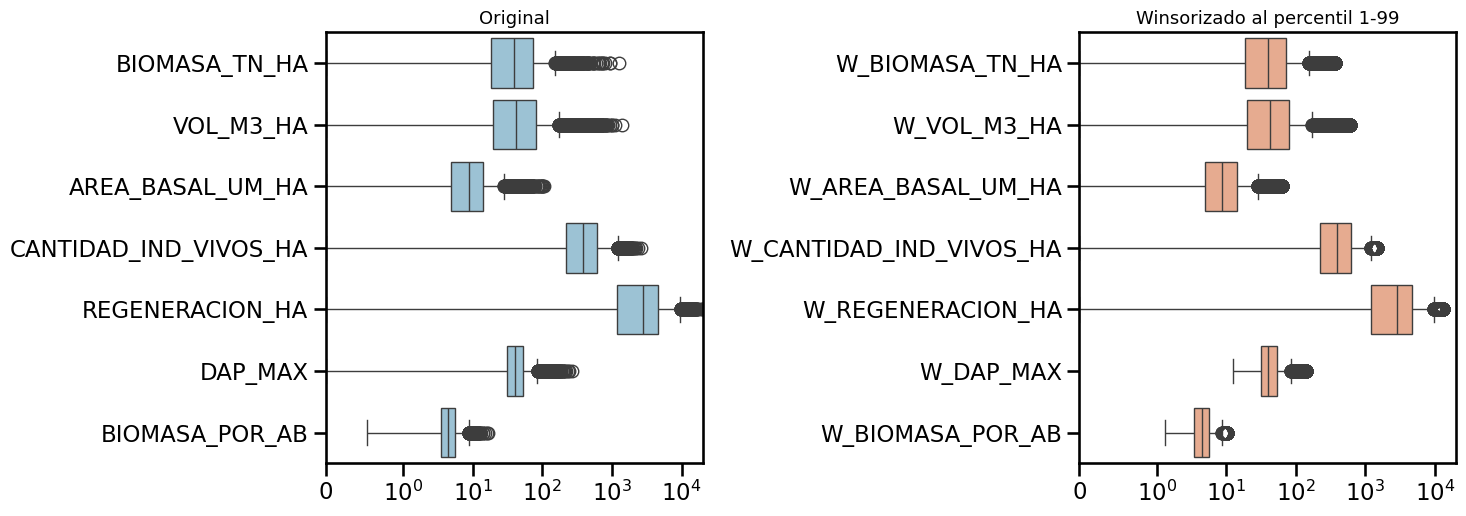

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True)

sns.boxplot(data=df_um[vars_winsorizar], orient='h', ax=axes[0], color='#92c5de')
axes[0].set_title('Original', fontsize=13)

sns.boxplot(data=df_um[[f'W_{c}' for c in vars_winsorizar]], orient='h', ax=axes[1], color='#f4a582')
axes[1].set_title('Winsorizado al percentil 1-99', fontsize=13)

for ax in axes:
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(0, 2e4)

plt.tight_layout()
plt.show()

La winsorización baja la asimetría de forma notoria sin mover las medianas ni perder filas. Es importante
subrayar que **el dataset principal no está winsorizado**: las columnas `W_*` conviven con las originales y el
usuario del dataset elige cuál usar según la tarea.

In [ ]:
resumen_variables = pd.DataFrame([
    {'Variable': 'CARBONO_TN_HA', 'Estado': 'Eliminada', 'Motivo': 'Redundante con BIOMASA_TN_HA (r=1.00)'},
    {'Variable': 'GANADO_OTRO_TIPO', 'Estado': 'Recodificada', 'Motivo': 'Nulo estructural → no_aplica'},
    {'Variable': 'ALTITUD', 'Estado': 'Imputada (KNN)', 'Motivo': '169 casos, R²=0.59 vs. imputar media'},
    {'Variable': 'SUBREG', 'Estado': 'Imputada (determinística)', 'Motivo': 'Heredada de UM o subregión única'},
    {'Variable': 'ESBELTEZ', 'Estado': 'Nueva (derivada)', 'Motivo': 'h/d × 100, indicador dasométrico'},
    {'Variable': 'SHANNON', 'Estado': 'Nueva (derivada)', 'Motivo': 'Diversidad ponderada por abundancia'},
    {'Variable': 'PRESION_ANTROPICA', 'Estado': 'Nueva (derivada)', 'Motivo': 'Índice de 4 componentes binarias'},

])
resumen_variables

,Variable,Estado,Motivo
0,CARBONO_TN_HA,Eliminada,Redundante con BIOMASA_TN_HA (r=1.00)
1,GANADO_OTRO_TIPO,Recodificada,Nulo estructural → no_aplica
2,ALTITUD,Imputada (KNN),"169 casos, R²=0.59 vs. imputar media"
3,SUBREG,Imputada (determinística),Heredada de UM o subregión única
4,ESBELTEZ,Nueva (derivada),"h/d × 100, indicador dasométrico"
5,SHANNON,Nueva (derivada),Diversidad ponderada por abundancia
6,PRESION_ANTROPICA,Nueva (derivada),Índice de 4 componentes binarias


### 2.9. Datasets curados

In [ ]:
df_um_final = df_um.copy()
df_ind_final = df_ind.copy()

# Dataset combinado: cada individuo con el contexto de su parcela (equivalente al del TP1, con las
# variables curadas y las nuevas)
cols_contexto = ['UM_ID_UM', 'REGION_OFC', 'SUBREG', 'PROVINCIA_NOMBRE', 'LATITUD', 'LONGITUD',
                 'ALTITUD', 'PENDIENTE_CATEGORIA', 'AREA_BASAL_UM_HA', 'BIOMASA_TN_HA',
                 'RIQUEZA_ESPECIES', 'SHANNON', 'DOMINANCIA', 'PRESION_ANTROPICA',
                 'SIN_IND_INVENTARIABLE', 'PROTOCOLO_COMPLETO']
cols_contexto = [c for c in cols_contexto if c in df_um_final.columns]
df_combinado = df_ind_final.merge(df_um_final[cols_contexto], on='UM_ID_UM',
                                  how='left', suffixes=('', '_UM'))

df_um_final.to_csv('INBN2_um_curado.csv', index=False)
df_ind_final.to_csv('INBN2_individuos_curado.csv', index=False)
df_combinado.to_csv('INBN2_combinado_curado.csv', index=False)

print("Archivos generados:")
print(f"  INBN2_um_curado.csv          -> {df_um_final.shape}")
print(f"  INBN2_individuos_curado.csv  -> {df_ind_final.shape}")
print(f"  INBN2_combinado_curado.csv   -> {df_combinado.shape}")

Archivos generados:
  INBN2_um_curado.csv          -> (3891, 106)
  INBN2_individuos_curado.csv  -> (101229, 28)
  INBN2_combinado_curado.csv   -> (101229, 43)


In [ ]:
comparacion_final = pd.DataFrame({
    'Tabla general (antes)': resumen_dataset(df_um_crudo, 'x'),
    'Tabla general (después)': resumen_dataset(df_um_final, 'x'),
    'Individuos (antes)': resumen_dataset(df_ind_crudo, 'x'),
    'Individuos (después)': resumen_dataset(df_ind_final, 'x'),
})
comparacion_final

,Tabla general (antes),Tabla general (después),Individuos (antes),Individuos (después)
filas,3891.00,3891.00,101229.00,101229.00
columnas,78.00,106.00,31.00,28.00
columnas numéricas,55.00,92.00,23.00,19.00
columnas no numéricas,23.00,14.00,8.00,9.00
columnas con algún nulo,72.00,64.00,10.00,6.00
% de celdas nulas,12.59,5.72,18.61,7.11
filas duplicadas,0.00,0.00,0.00,0.00


In [ ]:
nuevas_variables = pd.DataFrame([
    ('LATITUD / LONGITUD', 'UM', 'Coordenadas recuperadas del error de separador decimal'),
    ('SIN_IND_INVENTARIABLE', 'UM', 'Parcela relevada sin individuos leñosos inventariables'),
    ('TIENE_TOCONES', 'UM', 'Bandera de "no aplica" para las medias de tocones'),
    ('EN_CUENCA_PRIORITARIA', 'UM', 'La UM pertenece a una cuenca forestal prioritaria'),
    ('ALTITUD_IMPUTADA', 'UM', 'Marca las altitudes estimadas por KNN espacial'),
    ('PROTOCOLO_COMPLETO', 'UM', 'Relevamiento posterior a 2018 (bloque ganado/erosión completo)'),
    ('PROVINCIA_NOMBRE', 'UM', 'Código INDEC decodificado a nombre'),
    ('RIQUEZA_ESPECIES', 'UM', 'Cantidad de especies distintas en la parcela'),
    ('SHANNON', 'UM', 'Índice de diversidad de Shannon de la parcela'),
    ('DOMINANCIA', 'UM', 'Proporción de individuos de la especie más abundante'),
    ('DAP_MEDIO / DAP_MAX / DAP_DESVIO / DAP_CV', 'UM', 'Estructura diamétrica de la parcela'),
    ('ALTURA_MAX', 'UM', 'Altura del individuo más alto de la parcela'),
    ('PROP_IND_GRANDES', 'UM', 'Proporción de individuos con DAP >= 40 cm'),
    ('PROP_ARBUSTIVOS', 'UM', 'Proporción de individuos sin fuste único medible'),
    ('ESBELTEZ_MEDIA', 'UM', 'Relación altura/diámetro media de la parcela'),
    ('DENSIDAD_MADERA_PONDERADA', 'UM', 'Densidad de madera media ponderada por área basal'),
    ('PRESION_ANTROPICA', 'UM', 'Índice 0-1: tocones, incendios, pastoreo y ganado'),
    ('PFNM_N_ESPECIES', 'UM', 'Cantidad de productos forestales no madereros registrados'),
    ('N_FORMAS_VIDA', 'UM', 'Cantidad de formas de vida presentes en la UM'),
    ('BIOMASA_POR_AB', 'UM', 'Biomasa por unidad de área basal (proxy del porte medio)'),
    ('ALTITUD_CATEGORIA', 'UM', 'Altitud agrupada en rangos'),
    ('PENDIENTE_ORD / OTBN_ORD', 'UM', 'Versión ordinal de las categóricas ordenadas'),
    ('LOG_*', 'UM', 'Versión log1p de las variables muy asimétricas'),
    ('W_*', 'UM', 'Versión winsorizada al percentil 1-99'),
    ('ATIPICO_P99', 'UM', 'Cantidad de variables en las que la UM es atípica'),
    ('AREA_BASAL_M2', 'Individuo', 'Área basal recalculada desde el DAP (corrige el factor 100)'),
    ('ALTURA_M', 'Individuo', 'Altura curada (estimada donde la medición era anómala)'),
    ('ALTURA_CORREGIDA', 'Individuo', 'Marca los individuos con altura de campo anómala'),
    ('FACTOR_EXPANSION', 'Individuo', 'Factor de expansión a hectárea según parcela concéntrica'),
    ('ESBELTEZ', 'Individuo', 'Coeficiente de esbeltez (h/d x 100)'),
    ('ES_ARBUSTIVO / ES_GRANDE', 'Individuo', 'Forma de crecimiento y porte'),
    ('CLASE_DIAM_ORD', 'Individuo', 'Clase diamétrica como variable ordinal'),
    ('ESPECIE_FREQ / ESPECIE_AGRUPADA', 'Individuo', 'Encoding de la especie por frecuencia y top 30'),
], columns=['variable', 'nivel', 'descripción'])
nuevas_variables

,variable,nivel,descripción
0,LATITUD / LONGITUD,UM,Coordenadas recuperadas del error de separador...
1,SIN_IND_INVENTARIABLE,UM,Parcela relevada sin individuos leñosos invent...
2,TIENE_TOCONES,UM,"Bandera de ""no aplica"" para las medias de tocones"
3,EN_CUENCA_PRIORITARIA,UM,La UM pertenece a una cuenca forestal prioritaria
4,ALTITUD_IMPUTADA,UM,Marca las altitudes estimadas por KNN espacial
5,PROTOCOLO_COMPLETO,UM,Relevamiento posterior a 2018 (bloque ganado/e...
6,PROVINCIA_NOMBRE,UM,Código INDEC decodificado a nombre
7,RIQUEZA_ESPECIES,UM,Cantidad de especies distintas en la parcela
8,SHANNON,UM,Índice de diversidad de Shannon de la parcela
9,DOMINANCIA,UM,Proporción de individuos de la especie más abu...


## Conclusiones — TP2

**Sobre los errores de carga.** La aportación más significativa de este práctico no estaba prevista en el
diagnóstico del TP1: al cruzar variables que deberían guardar relaciones matemáticas exactas aparecieron tres
problemas que ninguna revisión de nulos o duplicados hubiera detectado. El área basal de los individuos del
Parque Chaqueño —el 76% del dataset— está 100 veces por debajo de su valor real mientras que la del resto del
país es correcta; las coordenadas de la tabla general perdieron el separador decimal
y son recuperables con exactitud (validado contra el GPS de los individuos, diferencia mediana de 0,0000°); y
122 altitudes del Parque Chaqueño están cargadas como cero cuando en esa región no hay bosque a nivel del mar.
Los tres se corrigieron antes de tocar los faltantes, porque de otro modo se habría imputado sobre datos malos.

**Sobre los valores faltantes.** Ninguna fila fue eliminada. La clasificación del TP1 se sostuvo, con una
corrección: los nulos de `VOL_M3` no eran residuales sin patrón sino los individuos arbustivos del Monte sin
fuste medible, el mismo grupo que ya se había identificado por otra vía. La regla que ordenó las decisiones fue
distinguir entre nulos que significan "cero" (una parcela sin árboles tiene 0 Tn/ha de biomasa, no biomasa
desconocida), nulos que significan "no aplica" (que se recodificaron con banderas para no perder esa
información) y nulos genuinos, los únicos que se imputaron. El caso más elaborado fue la altitud, imputada por
KNN sobre las coordenadas recuperadas: un ejemplo de cómo una corrección habilita otra.

**Sobre las variables.** Se descartaron 33 columnas entre las dos tablas por redundancia exacta, carácter
administrativo o cobertura insuficiente, y se generaron más de 30 nuevas. Las de composición y diversidad (riqueza, Shannon, dominancia)
llenan un vacío del dataset original: la tabla general describía cuánto bosque hay pero no de qué está hecho.
Las agregaciones se validaron reproduciendo los agregados que ya existían, lo que además confirmó los factores
de expansión de las parcelas concéntricas (10 y 39,3).

**Sobre los atípicos.** Los criterios estadísticos marcan entre el 3% y el 11% de las observaciones según el
método, pero ninguno distingue un error de un bosque excepcional. Al inspeccionar la cola alta aparece
coherencia total entre especie, región, diámetro y biomasa: los diámetros más grandes son quebrachos blancos
chaqueños y lengas patagónicas, y las parcelas más densas en biomasa son patagónicas y de selva. **No son
errores, pueden representar rodales con características estructurales especialmente relevantes.** La decisión fue conservarlos en el dataset principal,
marcarlos con una bandera, y entregar versiones winsorizadas al percentil 1-99 sólo como insumo para el
modelado. Los únicos valores realmente imposibles eran dos alturas de campo (58 m y 52,4 m, con el diámetro
copiado en la casilla de la altura), y quedaron resueltos al adoptar la columna de altura estimada del propio
INBN2.

**Sobre las transformaciones.** Se optó por `RobustScaler` sobre `StandardScaler` y `MinMaxScaler` porque en
distribuciones con esta asimetría la media y el desvío están contaminados por la propia cola. El encoding se
resolvió con cuatro estrategias distintas según la naturaleza de cada variable (binaria, ordinal, nominal de
baja cardinalidad, alta cardinalidad), evitando la solución uniforme que habría impuesto un orden inexistente
entre regiones o generado cientos de columnas vacías para las especies.

**Qué queda para el TP3** A partir de la exploración y curación realizadas en los dos primeros prácticos, el dataset quedó preparado para avanzar hacia distintas preguntas de modelado. El análisis permitió conocer con mayor profundidad la estructura de la información, las diferencias entre regiones, las relaciones entre las principales variables forestales y las limitaciones que deberán considerarse en la siguiente etapa.

Una primera alternativa consiste en trabajar con aprendizaje supervisado para estimar la biomasa por hectárea de las unidades de muestreo a partir de sus características estructurales y ambientales. La relación encontrada entre biomasa, diámetro, área basal, altura y densidad de la madera permite plantear si estas variables alcanzan para construir un modelo con una buena capacidad predictiva.

Otra posibilidad es estudiar la regeneración del bosque. En este caso, la pregunta sería si la presencia o el nivel de regeneración de una parcela puede predecirse a partir de sus características estructurales, ambientales y antrópicas. Este enfoque permitiría analizar qué variables se relacionan con las diferencias observadas entre las unidades de muestreo, sin interpretar esas relaciones necesariamente como causales.

Una tercera alternativa es abordar un problema de aprendizaje no supervisado para identificar grupos de unidades de muestreo con estructuras forestales similares. La pregunta sería si es posible reconocer tipologías de bosque a partir de variables como biomasa, área basal, altura, densidad, diversidad y regeneración, y analizar posteriormente cómo se distribuyen esos grupos entre las regiones forestales y qué condiciones ambientales o antrópicas los caracterizan.

La pregunta definitiva y el enfoque metodológico se seleccionarán para el TP3. Independientemente de la alternativa elegida, será necesario considerar el fuerte desbalance regional, la cobertura temporal incompleta de las variables de ganado y erosión y el 11,8 % de unidades sin información de pendiente.
